## 목적

2027.07.15 일자 수신한 *Scientific Reports* Refree 의 조언에 따라 Raw data 에 대한 least square fitting 을 수행한다.

In [6]:
import sys, os
sys.path.insert(1, os.path.realpath(os.path.pardir))
from specs import *
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import t
from matplotlib.transforms import ScaledTranslation
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

rawDir = "/Users/jiyong/data/0804_container_detector_data/"
pn1Dir = rawDir + "P1_SN1222/"
pn2Dir = rawDir + "P2_SN1215/"
pn1files0 = [f for f in listdir(pn1Dir) if isfile(join(pn1Dir, f)) and f.endswith('mca')]
pn2files0 = [f for f in listdir(pn2Dir) if isfile(join(pn2Dir, f)) and f.endswith('mca')]

pn1files = [None] * len(pn1files0)
pn2files = [None] * len(pn2files0)

for f1 in pn1files0:
    ddd = (f1[1:-4].split("_"))[-1]
    if ddd == "BKG":
        pn1files[0] = pn1Dir+f1
    else :
        q = int(ddd.split("-")[-1])
        pn1files[q] = pn1Dir+f1
for f2 in pn2files0:
    ddd = (f2[1:-4].split("_"))[-1]
    if ddd == "BKG":
        pn2files[0] = pn2Dir+f2
    else :
        q = int(ddd.split("-")[-1])
        pn2files[q] = pn2Dir+f2


Log =[
    [0, ["Bkg"], 0, 0],                            # 0
    [1, ["Am241",], 80, 420],                      # 1
    [2, ["Am241",], 180, 320],                     # 2
    [3, ["Am241",], 280, 220],                     # 3
    [4, ["Am241",], 460, 40],                      # 4
    [5, ["Cs137",], 70, 430],                      # 5
    [6, ["Cs137",], 130, 370],                     # 6
    [7, ["Cs137",], 300, 200],                     # 7
    [8, ["Cs137",], 390, 110],                     # 8
    [9, ["Co60",], 60, 440],                       # 9
    [10, ["Co60",], 120, 380],                      # 10
    [11, ["Co60",], 310, 190],                      # 11
    [12, ["Co60",], 470, 30],                       # 12
    [13, ["Co60", "Cs137"], 136, 359],              # 13
    [14, ["Am241", "Co60"], 287, 208],              # 14
    [15, ["Co60", "Cs137"], 361, 134],              # 15
    [16, ["Am241", "Cs137"], 163, 332],
    [17, ["Am241", "Co60", "Cs137"], 309, 186],
    [18, ["Am241", "Co60",], 210, 285, 153, 342],
    [19, ["Co60", "Cs137"], 285, 210, 367, 128],
    [20, ["Am241", "Cs137"], 85, 410, 173, 322],
    [21, ["Co60", "Cs137"], 316, 179, 223, 272],
    [22, [None,], ],
]



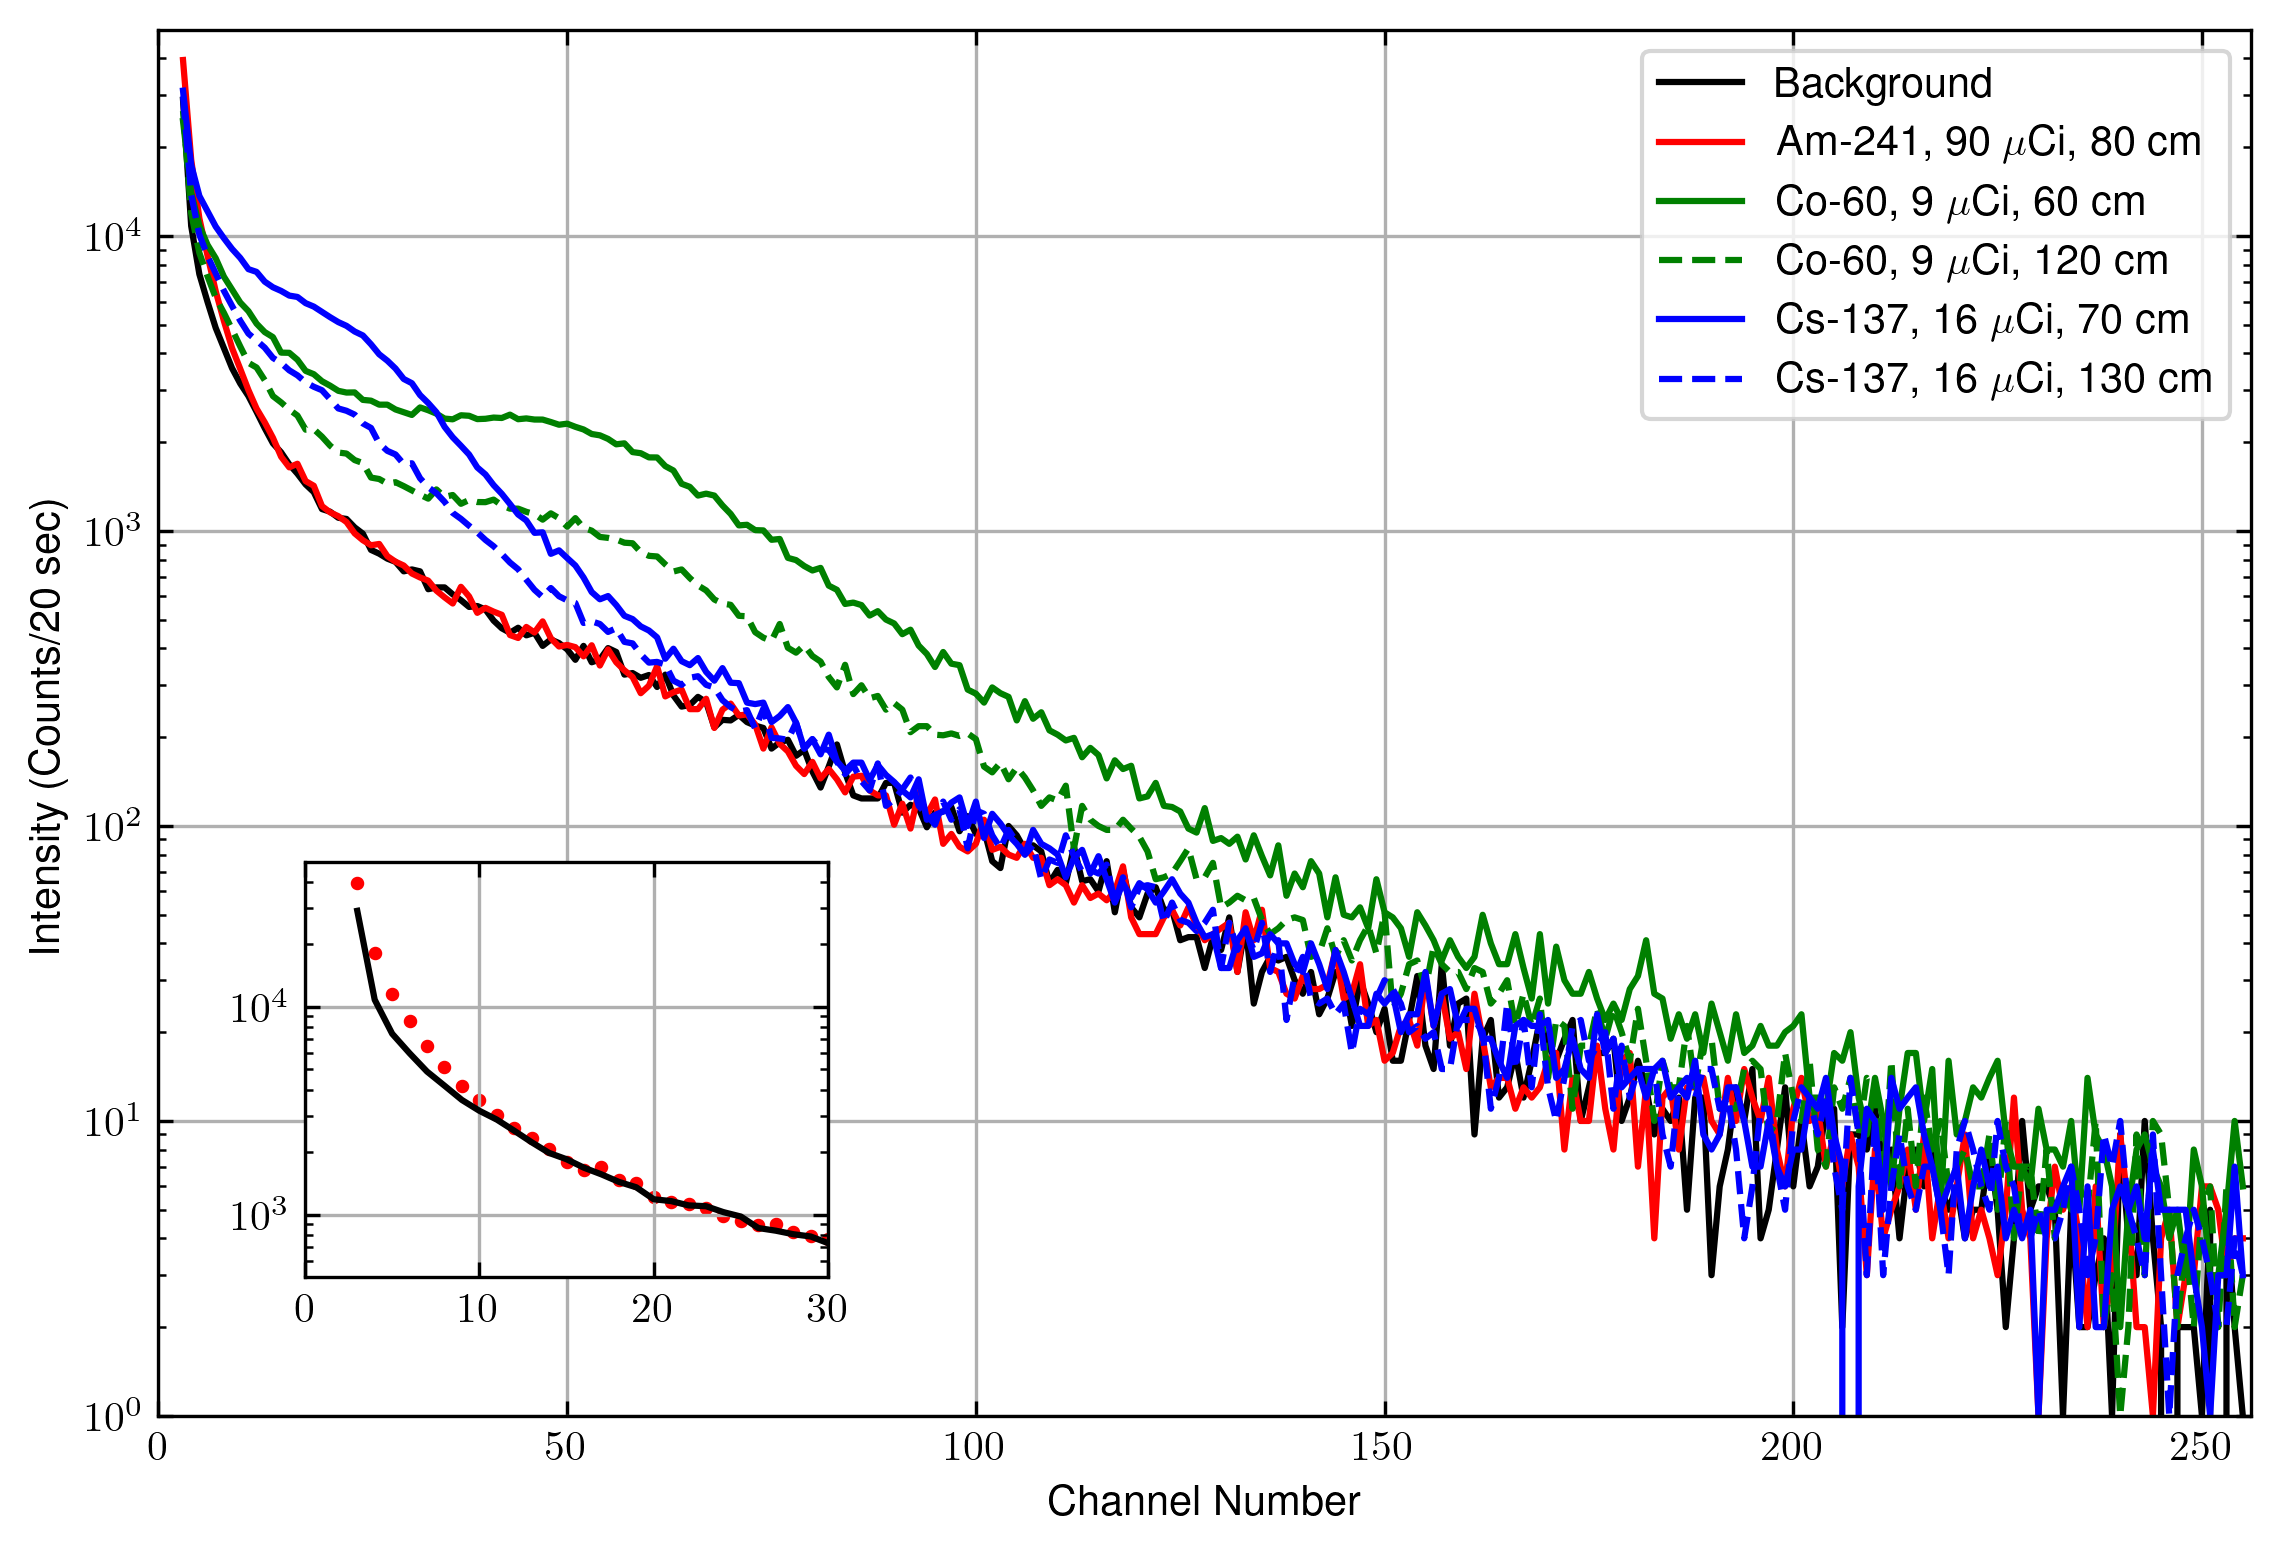

In [7]:
# PN1 data

ni = 3
Specs1 = pd.DataFrame( {
    "bkg" : read_mca(pn1files[0])[ni:], 
    "am_80" : read_mca(pn1files[1])[ni:],
    "cs_70" : read_mca(pn1files[5])[ni:],
    "cs_130" : read_mca(pn1files[6])[ni:],
    "co_120" : read_mca(pn1files[10])[ni:],
    "co_60" :  read_mca(pn1files[9])[ni:],
    "co_cs_136" : read_mca(pn1files[13])[ni:],
    "am_co_287" : read_mca(pn1files[14])[ni:],
    "co_cs_361" : read_mca(pn1files[15])[ni:],
    "am_cs_163" : read_mca(pn1files[16])[ni:],
    "am_co_cs_309" : read_mca(pn1files[17])[ni:],
    "am_210_co_153" : read_mca(pn1files[18])[ni:],
    "co_285_cs_367" : read_mca(pn1files[19])[ni:],
    "am_85_cs_173" : read_mca(pn1files[20])[ni:],
    "co_316_cs_223" : read_mca(pn1files[21])[ni:]
        
})

# PN2 data
Specs2 = pd.DataFrame( {
    "bkg" : read_mca(pn2files[0])[ni:], 
    "am_80" : read_mca(pn2files[1])[ni:],
    "cs_70" : read_mca(pn2files[5])[ni:],
    "cs_130" : read_mca(pn2files[6])[ni:],
    "co_120" : read_mca(pn2files[10])[ni:],
    "co_60" :  read_mca(pn2files[9])[ni:],
    "co_cs_136" : read_mca(pn2files[13])[ni:],
    "am_co_287" : read_mca(pn2files[14])[ni:],
    "co_cs_361" : read_mca(pn2files[15])[ni:],
    "am_cs_163" : read_mca(pn2files[16])[ni:],
    "am_co_cs_309" : read_mca(pn2files[17])[ni:],
    "am_210_co_153" : read_mca(pn2files[18])[ni:],
    "co_285_cs_367" : read_mca(pn2files[19])[ni:],
    "am_85_cs_173" : read_mca(pn2files[20])[ni:],
    "co_316_cs_223" : read_mca(pn2files[21])[ni:]
        
})

plt.figure(figsize=(9, 6), dpi=300)
channel = np.arange(ni,len(Specs1["bkg"])+ni)
plt.plot(channel, Specs1["bkg"], color="black", label = "Background")
plt.plot(channel, Specs1["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
plt.plot(channel, Specs1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
plt.plot(channel, Specs1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
plt.plot(channel, Specs1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
plt.plot(channel, Specs1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")

plt.legend()
plt.grid()
plt.yscale("log", base=10)
plt.ylim(1, 5e4)
plt.xlim(0, 256)
plt.xlabel("Channel Number")
plt.ylabel("Intensity (Counts/20 sec)")

ax = plt.gca()
x1, x2, y1, y2 = 0, 30, 5e2, 5.0e4  # subregion of the original image
axins = ax.inset_axes(
    [0.07, 0.1, 0.25, 0.3],
    xlim=(x1, x2), ylim=(y1, y2))#, xticklabels=[0, 20, 40], yticklabels=[1.0e3, 1.0e4])
axins.plot(channel, Specs1["bkg"], color="black", label = "Background")
axins.scatter(channel, Specs1["am_80"], color = "red", s=5, label = "Am-241, 90 $\\mu$Ci, 80 cm")
# axins.plot(channel, Specs1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
# axins.plot(channel, Specs1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
# axins.plot(channel, Specs1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
# axins.plot(channel, Specs1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")
axins.set_yscale("log", base=10)
axins.grid(True)
# plt.title("Fig 1")



## Raw data Fitting

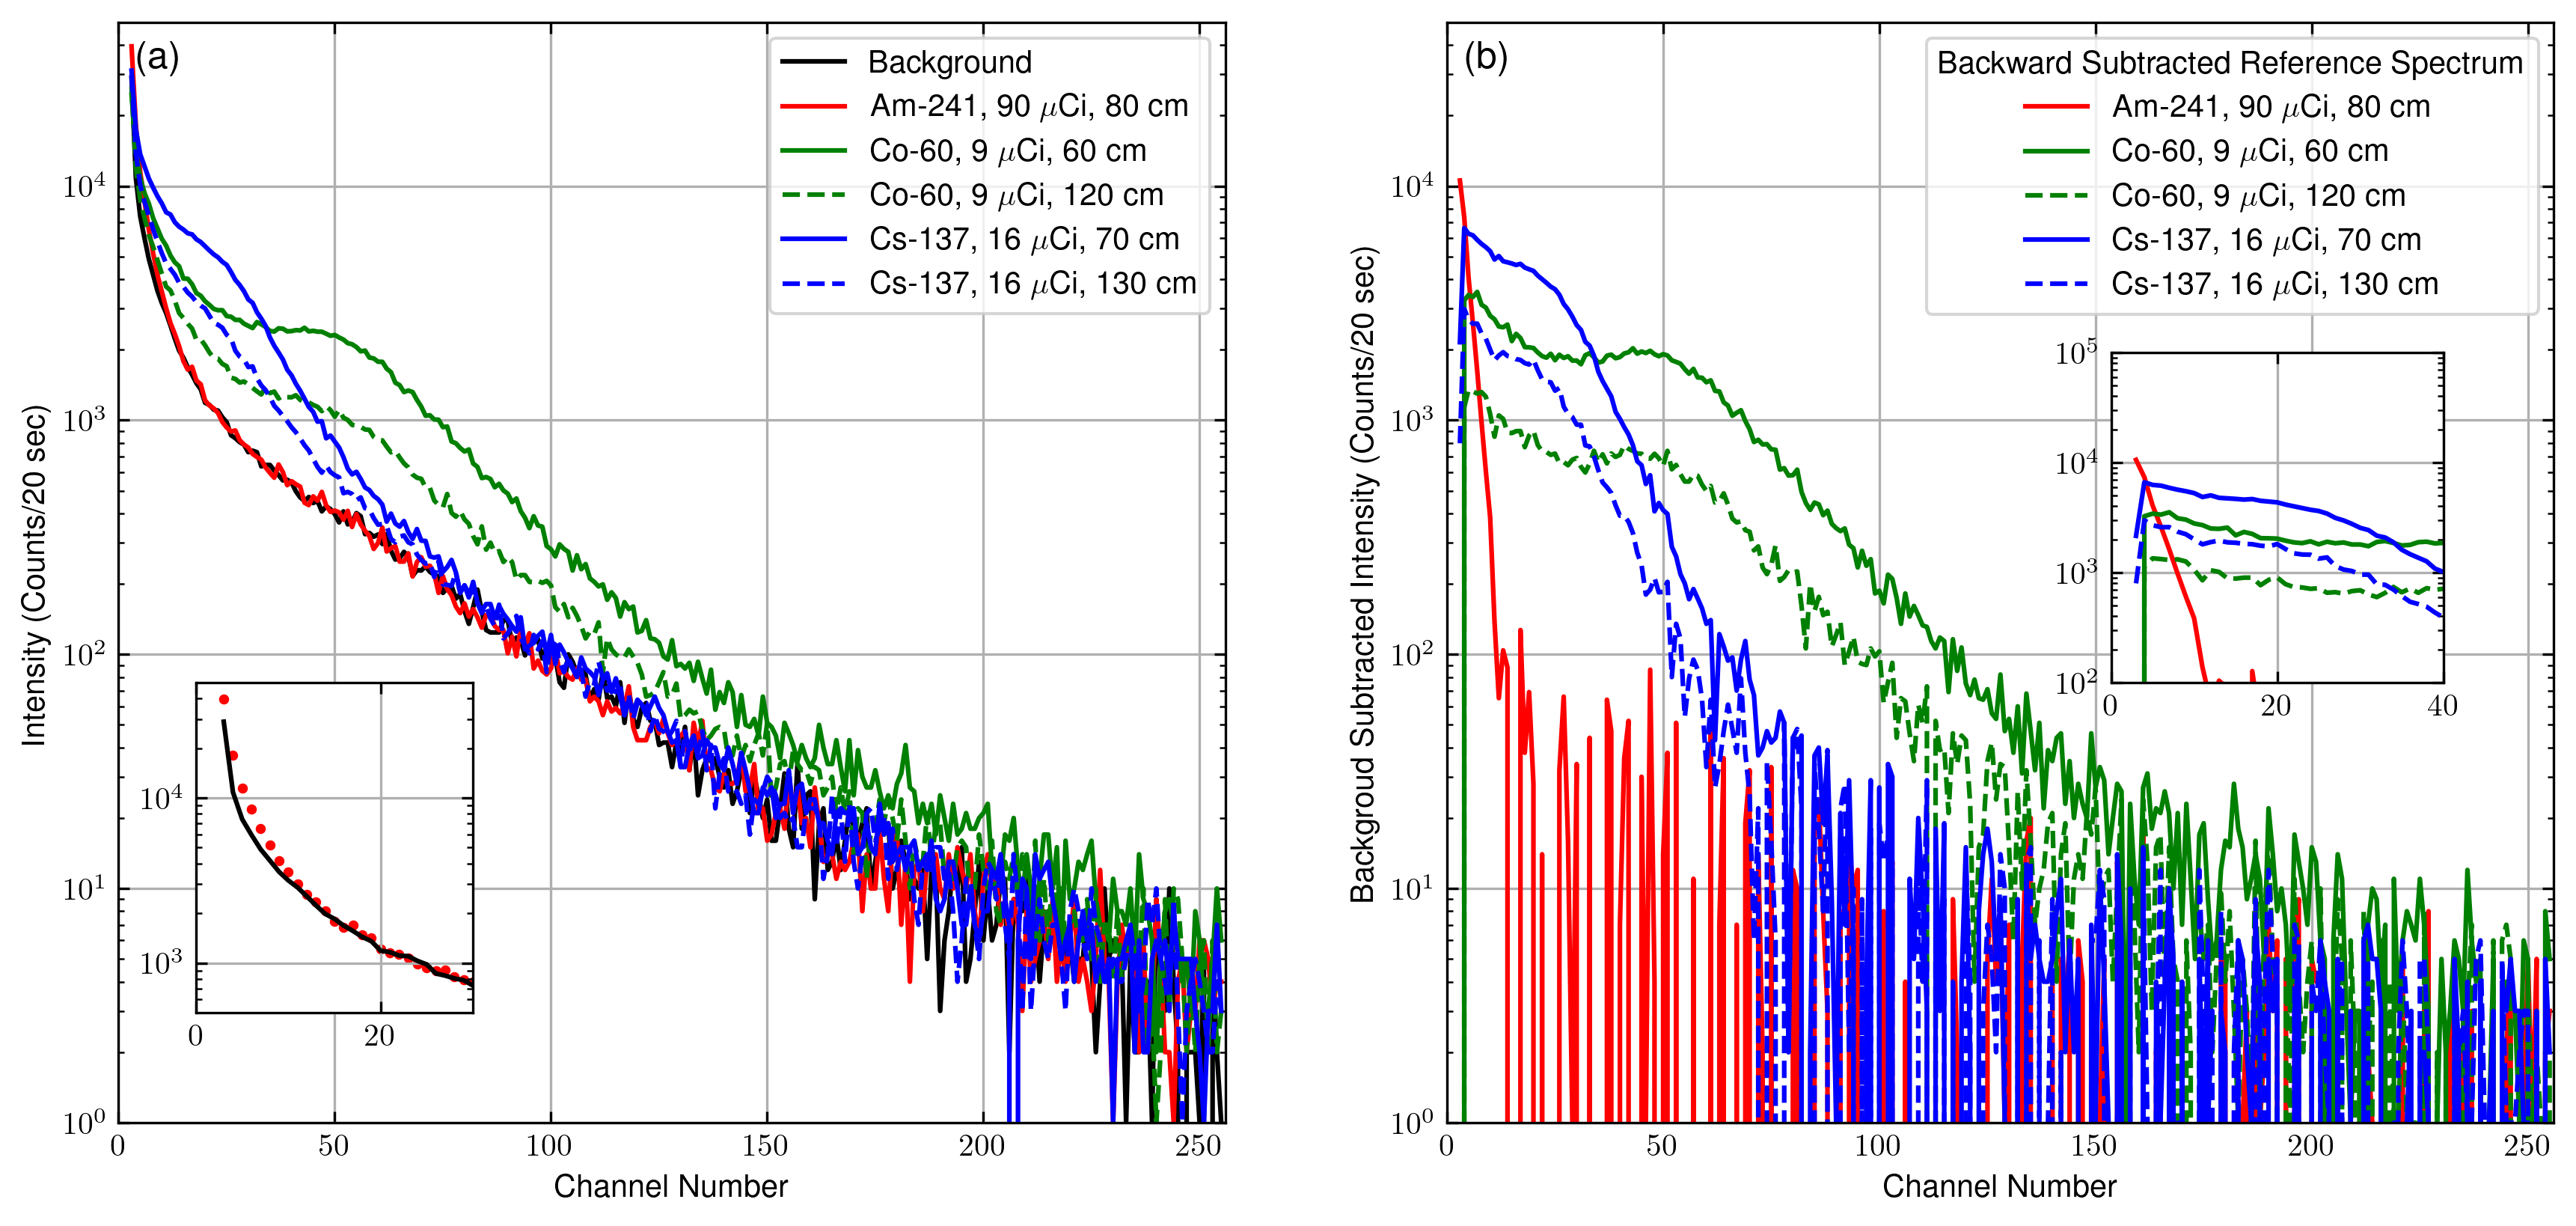

In [8]:
_raw1, _raw2, _bkg1, _bkg2, _rawsub1, _rawsub2= {}, {}, {}, {}, {}, {}
for kk in Specs1.keys():
    _raw1[kk] = Specs1[kk]
    if kk == "bkg":
        _bkg1 = Specs1[kk]
    else :
        _rawsub1[kk] = _raw1[kk] - _bkg1

for kk in Specs2.keys():
    _raw2[kk] = Specs2[kk]
    if kk == "bkg":
        _bkg2 = Specs2[kk]
    else :
        _rawsub2[kk] = _raw2[kk] - _bkg2


RAW1 = pd.DataFrame(_raw1)
RAW2 = pd.DataFrame(_raw2)
RAWSub1 = pd.DataFrame(_rawsub1)
RAWSub2 = pd.DataFrame(_rawsub2)

plt.figure(figsize=(14, 14), dpi=300)
plt.subplot(221)
channel = np.arange(ni,len(Specs1["bkg"])+ni)
plt.plot(channel, Specs1["bkg"], color="black", label = "Background")
plt.plot(channel, Specs1["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
plt.plot(channel, Specs1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
plt.plot(channel, Specs1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
plt.plot(channel, Specs1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
plt.plot(channel, Specs1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")

plt.legend()
plt.grid()
plt.yscale("log", base=10)
plt.ylim(1, 5e4)
plt.xlim(0, 256)
plt.xlabel("Channel Number")
plt.ylabel("Intensity (Counts/20 sec)")

ax = plt.gca()
x1, x2, y1, y2 = 0, 30, 5e2, 5.0e4  # subregion of the original image
axins = ax.inset_axes(
    [0.07, 0.1, 0.25, 0.3],
    xlim=(x1, x2), ylim=(y1, y2))#, xticklabels=[0, 20, 40], yticklabels=[1.0e3, 1.0e4])
axins.plot(channel, Specs1["bkg"], color="black", label = "Background")
axins.scatter(channel, Specs1["am_80"], color = "red", s=5, label = "Am-241, 90 $\\mu$Ci, 80 cm")
# axins.plot(channel, Specs1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
# axins.plot(channel, Specs1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
# axins.plot(channel, Specs1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
# axins.plot(channel, Specs1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")
axins.set_yscale("log", base=10)
axins.grid(True)
ax.annotate(
        "(a)",
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top')#, fontfamily='serif'
        # bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))
# plt.title("Fig 1")



# plt.figure(figsize=(14, 6), dpi=300)
plt.subplot(222)
#plt.plot(channel, RAWSub1["bkg"], color="black", label = "Background")
plt.plot(channel, RAWSub1["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
plt.plot(channel, RAWSub1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
plt.plot(channel, RAWSub1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
plt.plot(channel, RAWSub1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
plt.plot(channel, RAWSub1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")


plt.legend(title = "Backward Subtracted Reference Spectrum")
plt.grid()
plt.yscale("log", base=10)
plt.ylim(1, 5e4)
plt.xlim(0, 256)

plt.xlabel("Channel Number")
plt.ylabel("Backgroud Subtracted Intensity (Counts/20 sec)")

ax = plt.gca()
ff = plt.gcf()
ax.annotate(
        "(b)",
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top')#, fontfamily='serif'
        # bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))
x1, x2, y1, y2 = 0, 40, 1e2, 1.0e5  
axins = ax.inset_axes(
    [0.6, 0.4, 0.3, 0.3],
    xlim=(x1, x2), ylim=(y1, y2))#, xticklabels=[0, 20, 40], yticklabels=[1.0e3, 1.0e4])
#axins.plot(channel, RAWSub1["bkg"], color="black", label = "Background")
axins.plot(channel, RAWSub1["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
axins.plot(channel, RAWSub1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
axins.plot(channel, RAWSub1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
axins.plot(channel, RAWSub1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
axins.plot(channel, RAWSub1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")
axins.set_yscale("log", base=10)
axins.grid(True)

#plt.savefig("../../papers/ver260326Moon_revision01/newfigures/figure1.pdf")

Text(0.5, -0.5, '(b)')

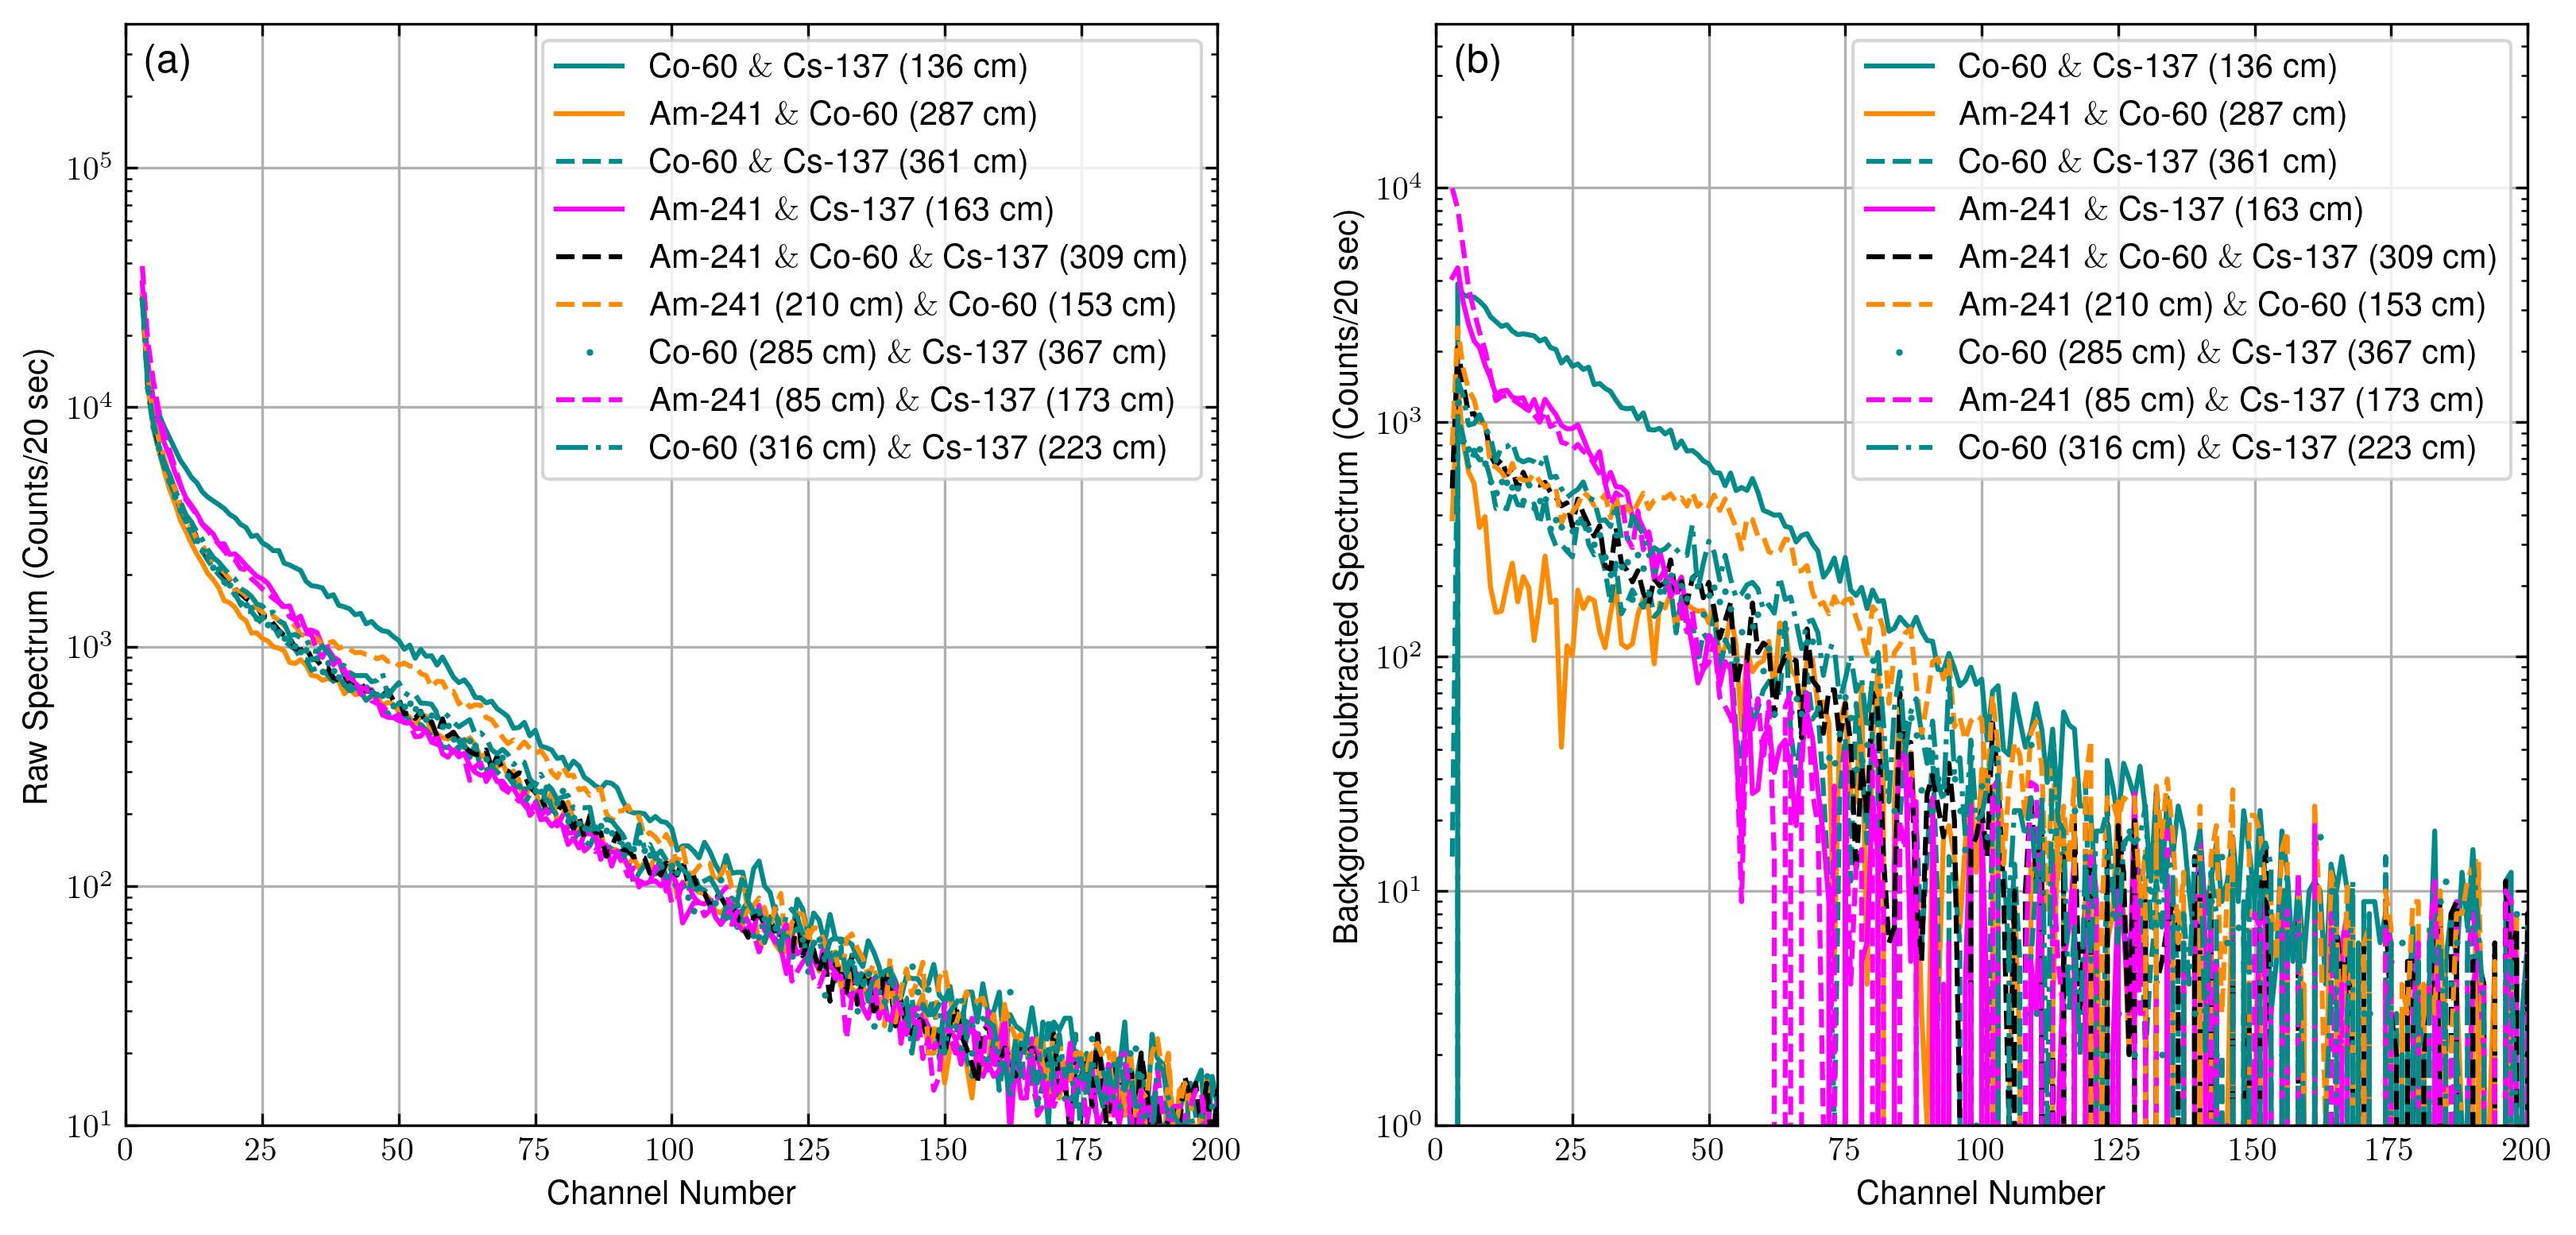

In [9]:
plt.figure(figsize=(13, 6), dpi = 300)
plt.subplot(121)
plt.plot(channel, RAW1["co_cs_136"], color = "darkcyan", label = "Co-60 $\\&$ Cs-137 (136 cm)")
plt.plot(channel, RAW1["am_co_287"], color = "darkorange", label = "Am-241 $\\&$ Co-60 (287 cm)")
plt.plot(channel, RAW1["co_cs_361"] , "--", color = "darkcyan", label = "Co-60 $\\&$  Cs-137 (361 cm)")
plt.plot(channel, RAW1["am_cs_163"], color = "magenta", label = "Am-241 $\\&$ Cs-137 (163 cm)")
plt.plot(channel, RAW1["am_co_cs_309"] , "--", color="black", label = "Am-241 $\\&$ Co-60 $\\&$ Cs-137 (309 cm)")
plt.plot(channel, RAW1["am_210_co_153"] , "--", color="darkorange", label = "Am-241 (210 cm) $\\&$ Co-60 (153 cm)")
plt.plot(channel, RAW1["co_285_cs_367"] , ".", ms=2, color="darkcyan", label = "Co-60 (285 cm) $\\&$ Cs-137 (367 cm)")
plt.plot(channel, RAW1["am_85_cs_173"] , "--", color="magenta", label = "Am-241 (85 cm) $\\&$ Cs-137 (173 cm)")
plt.plot(channel, RAW1["co_316_cs_223"] , "-.", color="darkcyan", label = "Co-60 (316 cm) $\\&$ Cs-137 (223 cm)")

plt.grid()
plt.yscale("log", base=10)
plt.ylim(10, 4e5)
plt.xlim(0, 200)
plt.xlabel("Channel Number")
plt.ylabel("Raw Spectrum (Counts/20 sec)")
plt.legend()
ax = plt.gca()
ax.annotate(
        "(a)",
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top')

# plt.subplot(122)
# plt.plot(channel, BCCSSub2["co_cs_136"], color = "cyan", label = "Co-60 $\\&$ Cs-137 (136 cm)")
# plt.plot(channel, BCCSSub2["am_co_287"], color = "olive", label = "Am-241 $\\&$ Co-60 (287 cm)")
# plt.plot(channel, BCCSSub2["co_cs_361"] , "--", color = "cyan", label = "Co-60 $\\&$ Cs-137 (361 cm)")
# plt.plot(channel, BCCSSub2["am_cs_63"], color = "magenta", label = "Am-241 $\\&$ Cs-137 (63 cm)")
# plt.plot(channel, BCCSSub2["am_co_cs_309"] , "--", color="black", label = "Am-241 $\\&$ Co-60 $\\&$ Cs-137 (309 cm)")
# plt.plot(channel, BCCSSub2["am_210_co_153"] , "--", color="olive", label = "Am-241 (210 cm) $\\&$ Co-60 (153 cm)")
# plt.plot(channel, BCCSSub2["co_285_cs_367"] , ".", color="cyan", label = "Co-60 (285 cm) $\\&$ Cs-137 (367 cm)")
# plt.plot(channel, BCCSSub2["am_85_cs_173"] , "--", color="magenta", label = "Am-241 (85 cm) $\\&$ Cs-137 (173 cm)")
# plt.plot(channel, BCCSSub2["co_316_cs_223"] , "-.", color="cyan", label = "Co-60 (316 cm) $\\&$ Cs-137 (223 cm)")
# plt.legend(title="Background Subtracted Channel Sum")
# plt.grid()
# plt.yscale("log", base=10)
# plt.ylim(1, 1.2e5)
# plt.xlim(0, 256)
# ax = plt.gca()
# ax.annotate(
#         "(b)",
#         xy=(0, 1), xycoords='axes fraction',
#         xytext=(+0.5, -0.5), textcoords='offset fontsize',
#         fontsize='large', verticalalignment='top')
plt.subplot(122)
plt.plot(channel, RAWSub1["co_cs_136"], color = "darkcyan", label = "Co-60 $\\&$ Cs-137 (136 cm)")
plt.plot(channel, RAWSub1["am_co_287"], color = "darkorange", label = "Am-241 $\\&$ Co-60 (287 cm)")
plt.plot(channel, RAWSub1["co_cs_361"] , "--", color = "darkcyan", label = "Co-60 $\\&$  Cs-137 (361 cm)")
plt.plot(channel, RAWSub1["am_cs_163"], color = "magenta", label = "Am-241 $\\&$ Cs-137 (163 cm)")
plt.plot(channel, RAWSub1["am_co_cs_309"] , "--", color="black", label = "Am-241 $\\&$ Co-60 $\\&$ Cs-137 (309 cm)")
plt.plot(channel, RAWSub1["am_210_co_153"] , "--", color="darkorange", label = "Am-241 (210 cm) $\\&$ Co-60 (153 cm)")
plt.plot(channel, RAWSub1["co_285_cs_367"] , ".", ms=2, color="darkcyan", label = "Co-60 (285 cm) $\\&$ Cs-137 (367 cm)")
plt.plot(channel, RAWSub1["am_85_cs_173"] , "--", color="magenta", label = "Am-241 (85 cm) $\\&$ Cs-137 (173 cm)")
plt.plot(channel, RAWSub1["co_316_cs_223"] , "-.", color="darkcyan", label = "Co-60 (316 cm) $\\&$ Cs-137 (223 cm)")

plt.grid()
plt.yscale("log", base=10)
plt.ylim(1, 5.0e4)
plt.xlim(0, 200)
plt.xlabel("Channel Number")
plt.ylabel("Background Subtracted Spectrum (Counts/20 sec)")
plt.legend(title = "Backward Subtracted Reference Spectrum")
plt.legend()
ax = plt.gca()
ax.annotate(
        "(b)",
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top')
#plt.savefig("../../papers/ver260326Moon_revision01/newfigures/figure2.pdf")

In [10]:
# def BCCSfit(params, spectrum, refspecs = {}, idf=None, plot=False):
#     """Fit the spectrum to a linear combination of reference spectra.
#     """ 
#     if idf == None :
#         idf = len(spectrum)
        
#     amspec = refspecs["Am"][0:idf]
#     cospec = refspecs["Co"][0:idf]
#     csspec = refspecs["Cs"][0:idf]
#     def detfunc(params, xdata, ydata):
#         a, b, c = params[0:3]
#         return ydata - (abs(a)*amspec + abs(b)*cospec + abs(c)*csspec)

    
#     fr1 = optimization.leastsq(detfunc, params, args=(np.arange(len(spectrum)), spectrum[0:idf]), full_output=True)
    
    
#     if plot:
#         plt.figure(figsize=(12, 6))
#         plt.plot(spectrum, label="Spectrum", color="black")
#         plt.plot(fr1[0]*amspec, label="Am-241", color="blue")
#         plt.plot(fr1[1]*cospec, label="Co-60", color="red")
#         plt.plot(fr1[2]*csspec, label="Cs-137", color="green")
#         plt.plot(fr1[0]*amspec + fr1[1]*cospec + fr1[2]*csspec, label="Fitted", color="violet")
#         plt.yscale("log", base=10)
#         plt.ylim(1.0, spectrum[0]*2)
#         plt.legend()
#         plt.title("Spectrum Fit")
#         plt.show()
#     return fr1[0:2]

def RAWfit(params, spectrum, refspecs = {}, idf=None, plot=False):
    """Fit the spectrum to a linear combination of reference spectra.
    """ 
    if idf == None :
        idf = len(spectrum)
    
    bkgspec = refspecs["bkg"][0:idf]    
    amspec = refspecs["Am"][0:idf] - bkgspec
    cospec = refspecs["Co"][0:idf] - bkgspec
    csspec = refspecs["Cs"][0:idf] - bkgspec
    
    def detfunc(xdata, a, b, c, d):
        
        return abs(a)*amspec + abs(b)*cospec + abs(c)*csspec + abs(d)*bkgspec

    popt, pconv = optimization.curve_fit(detfunc, np.arange(len(spectrum[0:idf])), spectrum[0:idf], params, absolute_sigma=True)
    
    # 표준오차(SE)와 95% 신뢰구간
    n, p = idf, len(popt)
    dof = max(0, n - p)
    se = np.sqrt(np.diag(pconv))
    tval = t.ppf(0.975, dof)
    ci = np.column_stack([popt - tval*se, popt + tval*se])

    if plot:
        plt.figure(figsize=(12, 6))
        plt.plot(spectrum, label="Spectrum", color="black")
        plt.plot(popt[0]*amspec, label="Am-241", color="blue")
        plt.plot(popt[1]*cospec, label="Co-60", color="red")
        plt.plot(popt[2]*csspec, label="Cs-137", color="green")
        plt.plot(popt[0]*amspec + popt[1]*cospec + popt[2]*csspec, label="Fitted", color="violet")
        plt.yscale("log", base=10)
        plt.ylim(1.0, spectrum[0]*2)
        plt.legend()
        plt.title("Spectrum Fit")
        plt.show()
    return popt, se, pconv

def RAWSubfit(params, spectrum, refspecs = {}, idf=None, plot=False):
    """Fit the spectrum to a linear combination of reference spectra.
    """ 
    if idf == None :
        idf = len(spectrum)
    
    amspec = refspecs["Am"][0:idf]
    cospec = refspecs["Co"][0:idf]
    csspec = refspecs["Cs"][0:idf]
    
    def detfunc(xdata, a,b,c):
        
        return abs(a)*amspec + abs(b)*cospec + abs(c)*csspec

    popt, pconv = optimization.curve_fit(detfunc, np.arange(len(spectrum[0:idf])), spectrum[0:idf], params, absolute_sigma=True)
    
    # 표준오차(SE)와 95% 신뢰구간
    n, p = idf, len(popt)
    dof = max(0, n - p)
    se = np.sqrt(np.diag(pconv))
    tval = t.ppf(0.975, dof)
    ci = np.column_stack([popt - tval*se, popt + tval*se])

    if plot:
        plt.figure(figsize=(12, 6))
        plt.plot(spectrum, label="Spectrum", color="black")
        plt.plot(popt[0]*amspec, label="Am-241", color="blue")
        plt.plot(popt[1]*cospec, label="Co-60", color="red")
        plt.plot(popt[2]*csspec, label="Cs-137", color="green")
        plt.plot(popt[0]*amspec + popt[1]*cospec + popt[2]*csspec, label="Fitted", color="violet")
        plt.yscale("log", base=10)
        plt.ylim(1.0, spectrum[0]*2)
        plt.legend()
        plt.title("Spectrum Fit")
        plt.show()
    return popt, se, pconv

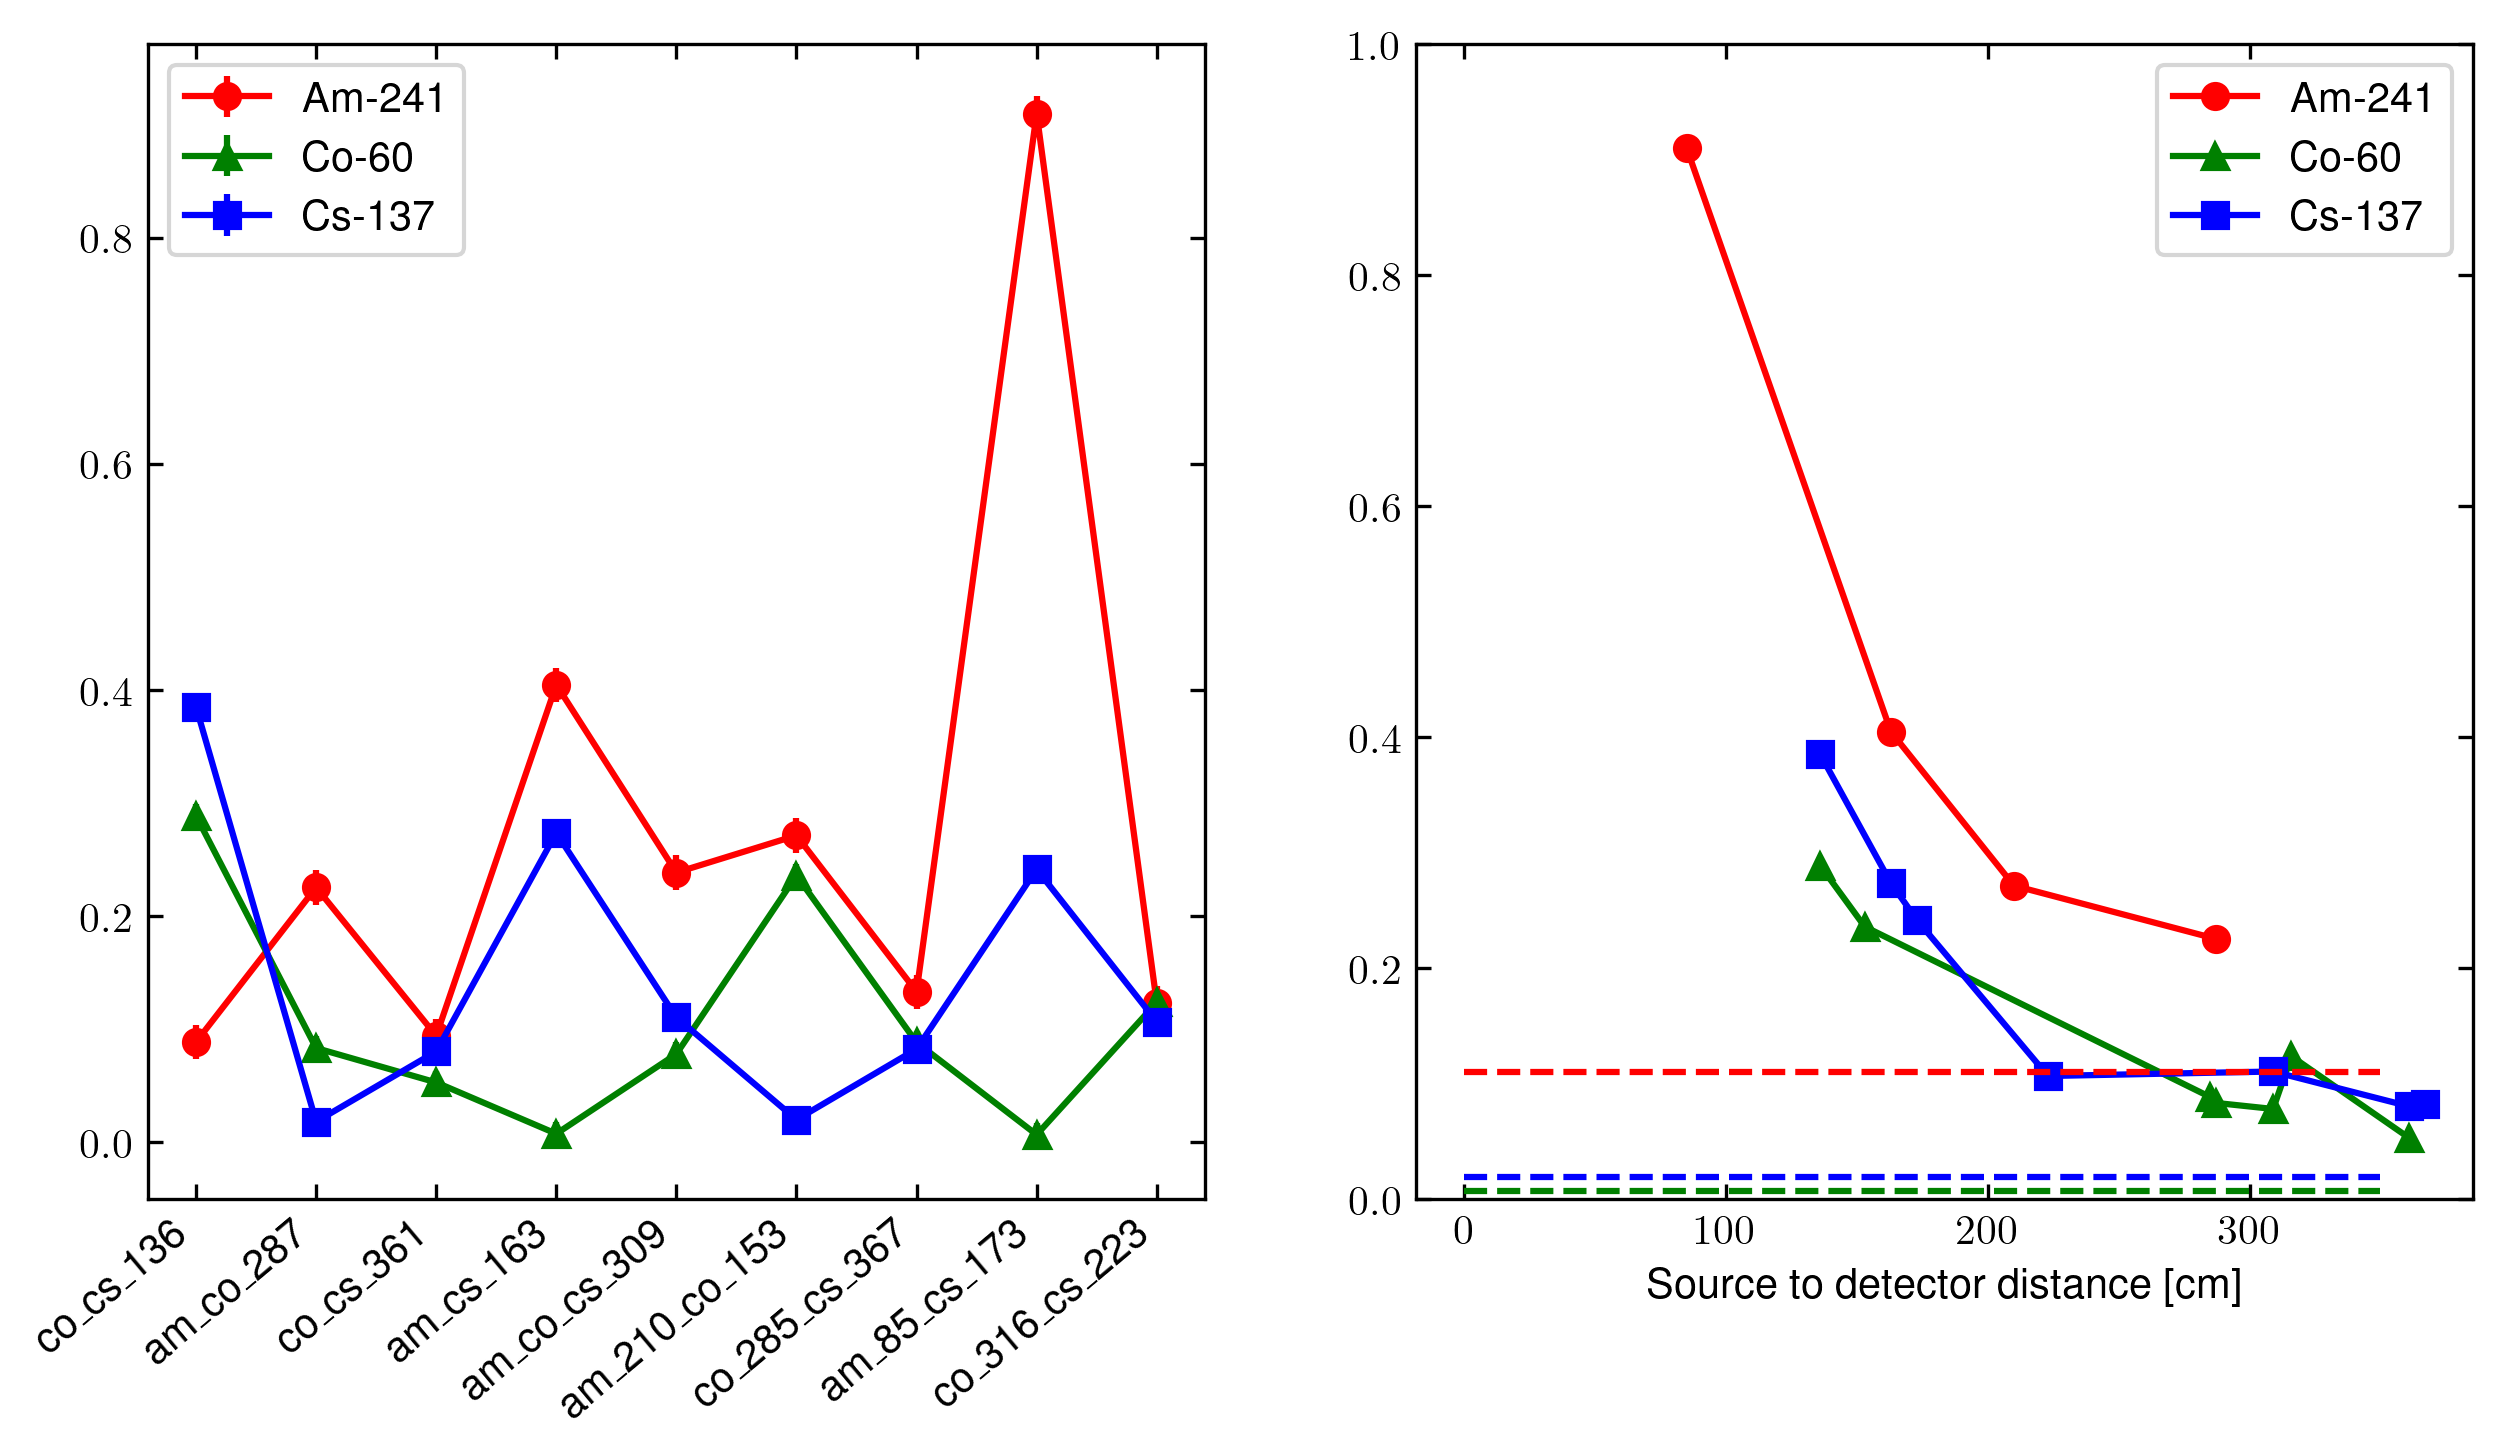

In [11]:
_refspec = {"Am" : RAW1["am_80"], "Co" :RAW1["co_60"], "Cs":RAW1["cs_70"], "bkg":RAW1["bkg"]}
mixed = ("co_cs_136", "am_co_287", "co_cs_361", "am_cs_163", "am_co_cs_309", "am_210_co_153",
         "co_285_cs_367", "am_85_cs_173", "co_316_cs_223")

RawFitResult0, RawFitResult = {}, {}
for kk in mixed :
     popt, se, pconv = RAWfit((0.3, 0.3, 0.3, 0.4), RAW1[kk], _refspec, 150, False)
     RawFitResult0[kk] = (popt, se, pconv)
     RawFitResult[kk] = {}
     RawFitResult[kk]["am"] = [float(c) for c in (float(popt[0]), float(np.sqrt(se[0])))]
     RawFitResult[kk]["co"] = [float(c) for c in (float(popt[1]), float(np.sqrt(se[1])))]
     RawFitResult[kk]["cs"] = [float(c) for c in (float(popt[2]), float(np.sqrt(se[2])))]
     RawFitResult[kk]["bkg"] = [float(c) for c in (float(popt[3]), float(np.sqrt(se[3])))]

v_am, v_co, v_cs, e_am, e_co, e_cs = [], [], [], [], [], []
for kk in mixed :
     v_am.append(RawFitResult[kk]["am"][0])
     e_am.append(RawFitResult[kk]["am"][1])
     v_co.append(RawFitResult[kk]["co"][0])
     e_co.append(RawFitResult[kk]["co"][1])
     v_cs.append(RawFitResult[kk]["cs"][0])
     e_cs.append(RawFitResult[kk]["cs"][1])

plt.figure(figsize=(10, 5), dpi = 300)
plt.subplot(121)
plt.errorbar(mixed, v_am, e_am, color="red", marker="o", label = "Am-241")
plt.errorbar(mixed, v_co, e_co, color="green", marker="^", label = "Co-60")
plt.errorbar(mixed, v_cs, e_cs, color="blue", marker="s", label = "Cs-137")
ax=plt.gca()
ax.set_xticks(np.arange(0, len(mixed)))
ax.set_xticklabels(mixed, rotation=40, ha='right')
# plt.yscale("log", base=10)
plt.legend()

plt.subplot(122)
amx = np.array([287, 163, 210, 85])
amy = np.array([RawFitResult["am_co_287"]["am"][0], RawFitResult["am_cs_163"]["am"][0], RawFitResult["am_210_co_153"]["am"][0], RawFitResult["am_85_cs_173"]["am"][0]])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")

cox = np.array([136, 287, 361, 309, 153, 285, 316])
coy = np.array([RawFitResult["co_cs_136"]["co"][0], RawFitResult["am_co_287"]["co"][0], RawFitResult["co_cs_361"]["co"][0], RawFitResult["am_co_cs_309"]["co"][0], RawFitResult["am_210_co_153"]["co"][0], RawFitResult["co_285_cs_367"]["co"][0], RawFitResult["co_316_cs_223"]["co"][0]])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 223])
csy = np.array([RawFitResult["co_cs_136"]["cs"][0], RawFitResult["co_cs_361"]["cs"][0], RawFitResult["am_cs_163"]["cs"][0], RawFitResult["am_co_cs_309"]["cs"][0], RawFitResult["co_285_cs_367"]["cs"][0], RawFitResult["am_85_cs_173"]["cs"][0], RawFitResult["co_316_cs_223"]["cs"][0]])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(0, 1)
plt.xlabel("Source to detector distance [cm]")

amzero, cozero, cszero, qs= [] , [], [], []

for ks in mixed :
     if "am" not in ks :
          amzero.append(RawFitResult[ks]["am"][0])
          
     if "co" not in ks :
          cozero.append(RawFitResult[ks]["co"][0])
          
     if "cs" not in ks :
          cszero.append(RawFitResult[ks]["cs"][0])
          qs.append(ks)

plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )

plt.legend()


In [20]:
RawFitResult

{'co_cs_136': {'am': [0.0885061105455027, 0.015190158592054113],
  'co': [0.2885794855514817, 0.01036519245707222],
  'cs': [0.3849542531402762, 0.009371307905079174],
  'bkg': [0.9739774751642092, 0.010110775426893693]},
 'am_co_287': {'am': [0.2252863565893504, 0.015190156593898385],
  'co': [0.08315417313085502, 0.010365192737271657],
  'cs': [0.018036956940019524, 0.009371307490581548],
  'bkg': [0.9426689300624985, 0.010110773688360818]},
 'co_cs_361': {'am': [0.09398998034611623, 0.01519015779219606],
  'co': [0.0527474024503203, 0.010365192608362798],
  'cs': [0.08013495656751862, 0.00937130763377108],
  'bkg': [0.968986569380839, 0.010110774747205014]},
 'am_cs_163': {'am': [0.40453605477437177, 0.015190155850170263],
  'co': [0.007347710945954822, 0.010365188483938767],
  'cs': [0.27343672766210037, 0.009371313385242707],
  'bkg': [0.9769219033516059, 0.010110777358348364]},
 'am_co_cs_309': {'am': [0.23839787142921146, 0.01519015715770738],
  'co': [0.07787843987146514, 0.010

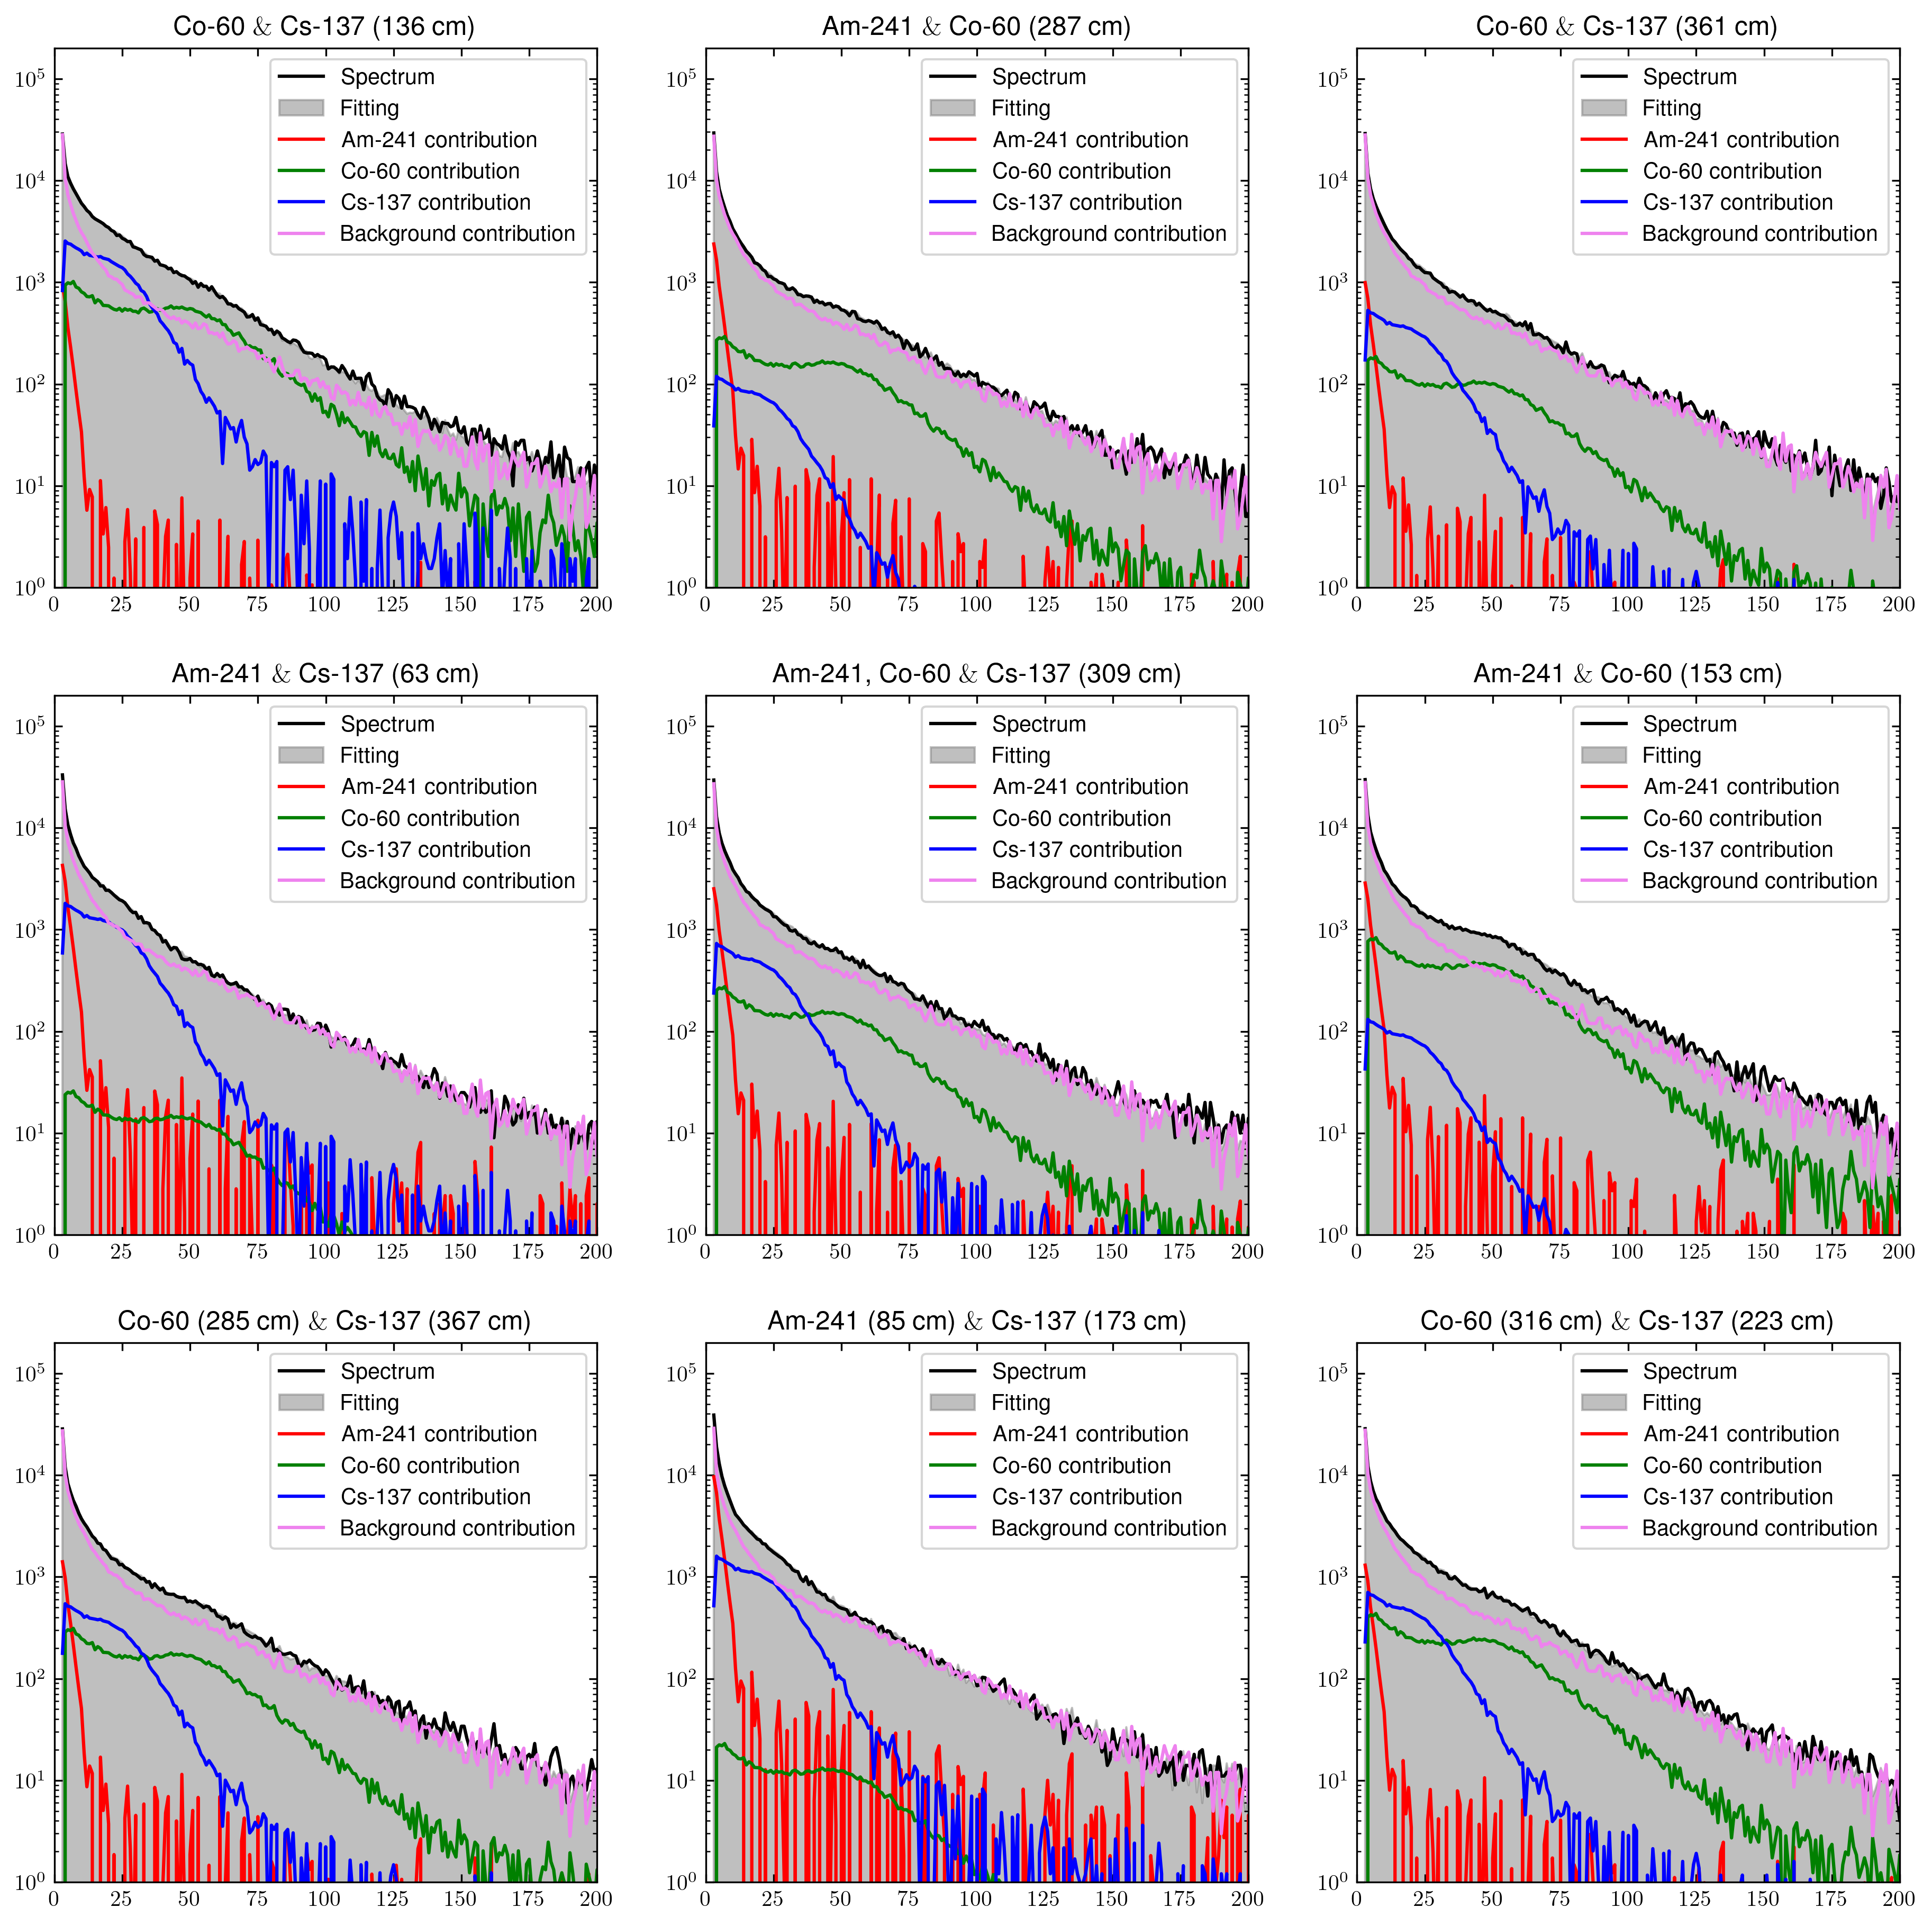

In [13]:
chan1, chan2 = 0, 200

plt.figure(figsize=(15, 15), dpi=300)
plt.subplot(331)
kk = "co_cs_136"
plt.plot(channel, RAW1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"])+ RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]) + RawFitResult[kk]['cs'][0]* (_refspec["Cs"] -_refspec["bkg"]) + RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"]), color="red", label = "Am-241 contribution")
plt.plot(channel, RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]), color="green", label = "Co-60 contribution")
plt.plot(channel, RawFitResult[kk]['cs'][0] * (_refspec["Cs"] - _refspec["bkg"]), color="blue", label = "Cs-137 contribution")
plt.plot(channel, RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="violet", label = "Background contribution")
plt.title("Co-60 $\\&$ Cs-137 (136 cm)")
plt.xlim(chan1, chan2)
plt.ylim(1, 2.0e5)
plt.yscale("log", base=10)
plt.legend(loc=1)

plt.subplot(332)
kk = "am_co_287"
plt.plot(channel, RAW1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"])+ RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]) + RawFitResult[kk]['cs'][0]* (_refspec["Cs"] -_refspec["bkg"]) + RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"]), color="red", label = "Am-241 contribution")
plt.plot(channel, RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]), color="green", label = "Co-60 contribution")
plt.plot(channel, RawFitResult[kk]['cs'][0] * (_refspec["Cs"] - _refspec["bkg"]), color="blue", label = "Cs-137 contribution")
plt.plot(channel, RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="violet", label = "Background contribution")
plt.title("Am-241 $\\&$ Co-60 (287 cm)")
plt.xlim(chan1, chan2)
plt.ylim(1, 2.0e5)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(333)
kk = "co_cs_361"
plt.plot(channel, RAW1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"])+ RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]) + RawFitResult[kk]['cs'][0]* (_refspec["Cs"] -_refspec["bkg"]) + RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"]), color="red", label = "Am-241 contribution")
plt.plot(channel, RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]), color="green", label = "Co-60 contribution")
plt.plot(channel, RawFitResult[kk]['cs'][0] * (_refspec["Cs"] - _refspec["bkg"]), color="blue", label = "Cs-137 contribution")
plt.plot(channel, RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="violet", label = "Background contribution")
plt.title("Co-60 $\\&$ Cs-137 (361 cm)")
plt.xlim(chan1, chan2)
plt.ylim(1, 2.0e5)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(334)
kk = 'am_cs_163'
plt.plot(channel, RAW1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"])+ RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]) + RawFitResult[kk]['cs'][0]* (_refspec["Cs"] -_refspec["bkg"]) + RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"]), color="red", label = "Am-241 contribution")
plt.plot(channel, RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]), color="green", label = "Co-60 contribution")
plt.plot(channel, RawFitResult[kk]['cs'][0] * (_refspec["Cs"] - _refspec["bkg"]), color="blue", label = "Cs-137 contribution")
plt.plot(channel, RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="violet", label = "Background contribution")
plt.title("Am-241 $\\&$ Cs-137 (63 cm)")
plt.xlim(chan1, chan2)
plt.ylim(1, 2.0e5)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(335)
kk = 'am_co_cs_309'
plt.plot(channel, RAW1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"])+ RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]) + RawFitResult[kk]['cs'][0]* (_refspec["Cs"] -_refspec["bkg"]) + RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"]), color="red", label = "Am-241 contribution")
plt.plot(channel, RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]), color="green", label = "Co-60 contribution")
plt.plot(channel, RawFitResult[kk]['cs'][0] * (_refspec["Cs"] - _refspec["bkg"]), color="blue", label = "Cs-137 contribution")
plt.plot(channel, RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="violet", label = "Background contribution")
plt.title("Am-241, Co-60 $\\&$ Cs-137 (309 cm)")
plt.xlim(chan1, chan2)
plt.ylim(1, 2.0e5)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(336)
kk = 'am_210_co_153'
plt.plot(channel, RAW1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"])+ RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]) + RawFitResult[kk]['cs'][0]* (_refspec["Cs"] -_refspec["bkg"]) + RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"]), color="red", label = "Am-241 contribution")
plt.plot(channel, RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]), color="green", label = "Co-60 contribution")
plt.plot(channel, RawFitResult[kk]['cs'][0] * (_refspec["Cs"] - _refspec["bkg"]), color="blue", label = "Cs-137 contribution")
plt.plot(channel, RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="violet", label = "Background contribution")
plt.xlim(chan1, chan2)
plt.title("Am-241 $\\&$ Co-60 (153 cm)")
plt.ylim(1, 2.0e5)
plt.yscale("log", base=10)
plt.legend(loc=1)

plt.subplot(337)
kk = 'co_285_cs_367'
plt.plot(channel, RAW1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"])+ RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]) + RawFitResult[kk]['cs'][0]* (_refspec["Cs"] -_refspec["bkg"]) + RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"]), color="red", label = "Am-241 contribution")
plt.plot(channel, RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]), color="green", label = "Co-60 contribution")
plt.plot(channel, RawFitResult[kk]['cs'][0] * (_refspec["Cs"] - _refspec["bkg"]), color="blue", label = "Cs-137 contribution")
plt.plot(channel, RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="violet", label = "Background contribution")
plt.title("Co-60 (285 cm) $\\&$ Cs-137 (367 cm)")
plt.xlim(chan1, chan2)
plt.ylim(1, 2.0e5)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(338)
kk = 'am_85_cs_173'
plt.plot(channel, RAW1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"])+ RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]) + RawFitResult[kk]['cs'][0]* (_refspec["Cs"] -_refspec["bkg"]) + RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"]), color="red", label = "Am-241 contribution")
plt.plot(channel, RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]), color="green", label = "Co-60 contribution")
plt.plot(channel, RawFitResult[kk]['cs'][0] * (_refspec["Cs"] - _refspec["bkg"]), color="blue", label = "Cs-137 contribution")
plt.plot(channel, RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="violet", label = "Background contribution")
plt.title("Am-241 (85 cm) $\\&$ Cs-137 (173 cm)")
plt.xlim(chan1, chan2)
plt.ylim(1, 2.0e5)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(339)
kk = 'co_316_cs_223'
plt.plot(channel, RAW1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"])+ RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]) + RawFitResult[kk]['cs'][0]* (_refspec["Cs"] -_refspec["bkg"]) + RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawFitResult[kk]['am'][0] * (_refspec["Am"] - _refspec["bkg"]), color="red", label = "Am-241 contribution")
plt.plot(channel, RawFitResult[kk]['co'][0] * (_refspec["Co"] - _refspec["bkg"]), color="green", label = "Co-60 contribution")
plt.plot(channel, RawFitResult[kk]['cs'][0] * (_refspec["Cs"] - _refspec["bkg"]), color="blue", label = "Cs-137 contribution")
plt.plot(channel, RawFitResult[kk]['bkg'][0] * _refspec["bkg"], color="violet", label = "Background contribution")
plt.title( "Co-60 (316 cm) $\\&$ Cs-137 (223 cm)")
plt.xlim(chan1, chan2)
plt.ylim(1, 2.0e5)
plt.yscale("log", base=10)
plt.legend()

# plt.savefig("../../src/newfigures/fit_BGSub.pdf")

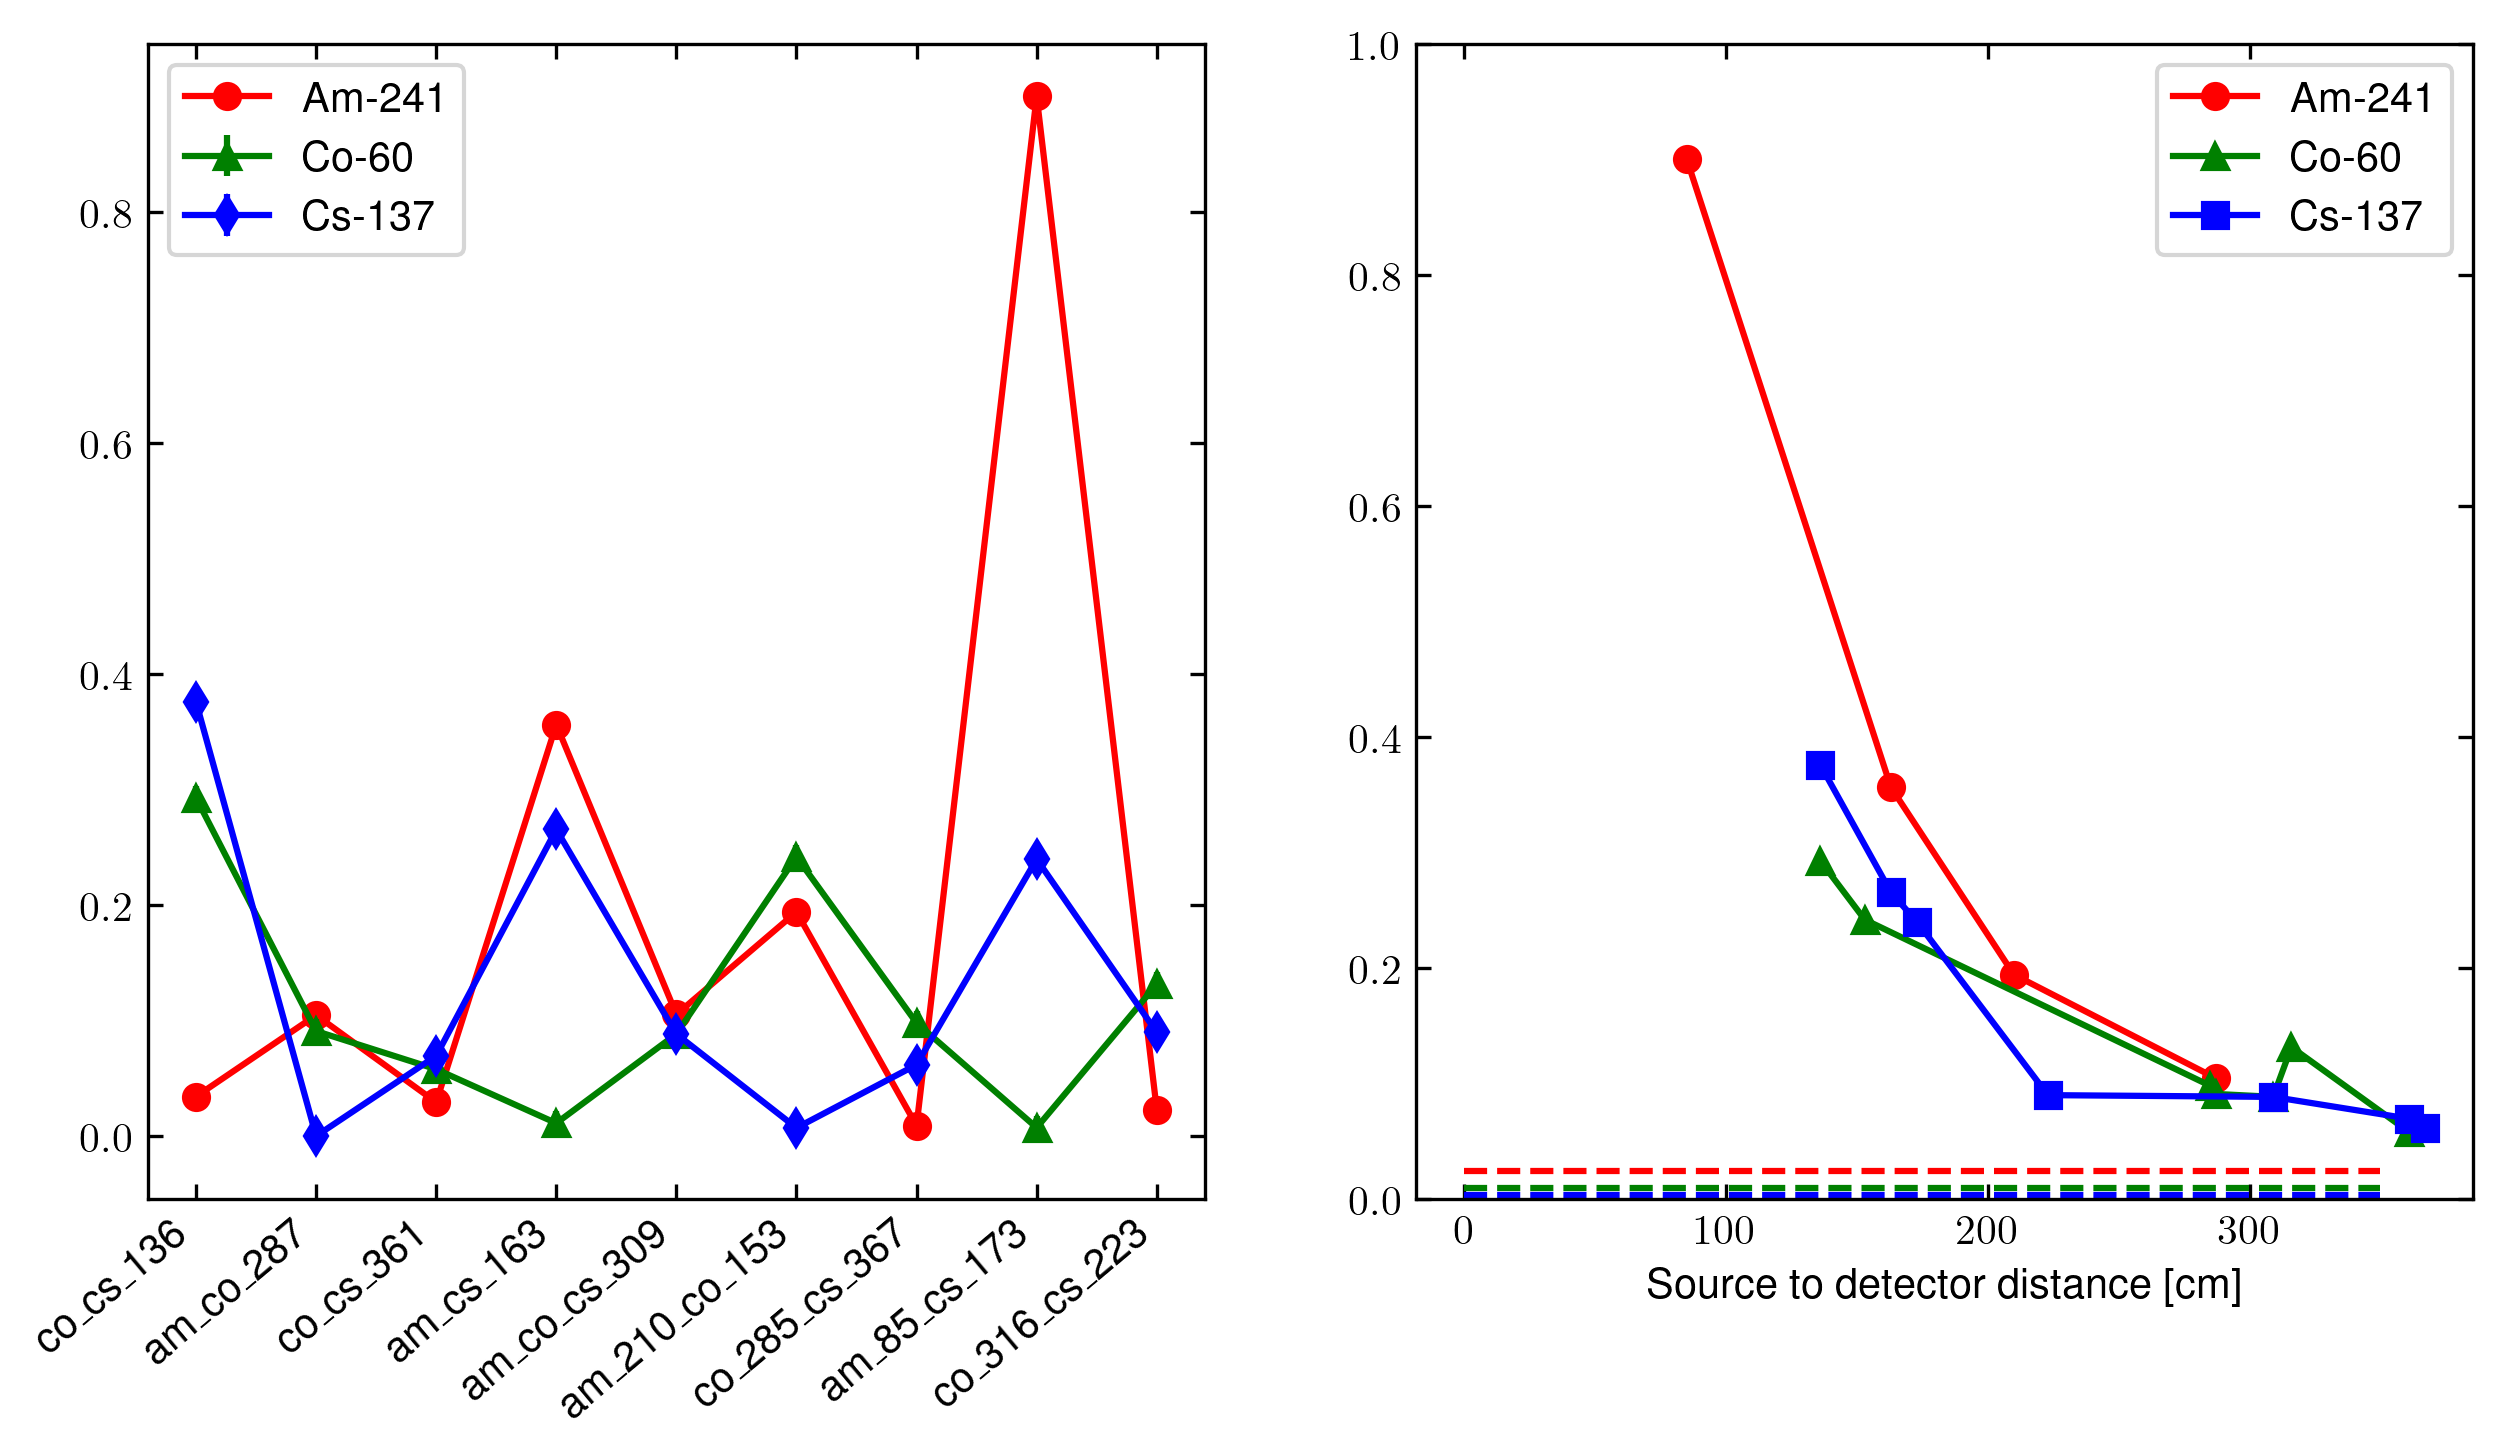

In [14]:
_refspecSub= {"Am" : RAWSub1["am_80"], "Co" :RAWSub1["co_60"], "Cs":RAWSub1["cs_70"]}
mixed = ("co_cs_136", "am_co_287", "co_cs_361", "am_cs_163", "am_co_cs_309", "am_210_co_153",
         "co_285_cs_367", "am_85_cs_173", "co_316_cs_223")

# RawSubFitResult = {}
# for kk in mixed :
#      RawSubFitResult[kk] = BCCSfit((0.5, 0.5, 0.5), RAWSub1[kk], _refspecSub, 100, False)

Nchan=60
Nchan=150
RawSubFitResult0, RawSubFitResult = {}, {}
for kk in mixed :
     popt2, se2, pconv2 = RAWSubfit((0.5, 0.5, 0.5), RAWSub1[kk], _refspecSub, Nchan, False)
     RawSubFitResult0[kk] = (popt2, se2, pconv2)
     RawSubFitResult[kk] = {}
     RawSubFitResult[kk]["am"] = [float(c) for c in (float(popt2[0]), float(np.sqrt(se2[0])))]
     RawSubFitResult[kk]["co"] = [float(c) for c in (float(popt2[1]), float(np.sqrt(se2[1])))]
     RawSubFitResult[kk]["cs"] = [float(c) for c in (float(popt2[2]), float(np.sqrt(se2[2])))]

v_am, v_co, v_cs, e_am, e_co, e_cs = [], [], [], [], [], []
for kk in mixed :
     v_am.append(RawSubFitResult[kk]["am"][0])
     e_am.append(RawSubFitResult[kk]["am"][1])
     v_co.append(RawSubFitResult[kk]["co"][0])
     e_co.append(RawSubFitResult[kk]["co"][1])
     v_cs.append(RawSubFitResult[kk]["cs"][0])
     e_cs.append(RawSubFitResult[kk]["cs"][1])

plt.figure(figsize=(10, 5), dpi = 300)
plt.subplot(121)
#plt.errorbar(mixed, v_am, e_am, color="red", marker="o", label = "Am-241")
plt.plot(mixed, v_am, color="red", marker="o", label = "Am-241")
plt.errorbar(mixed, v_co, e_co, color="green", marker="^", label = "Co-60")
plt.errorbar(mixed, v_cs, e_cs, color="blue", marker="d", label = "Cs-137")
ax=plt.gca()
ax.set_xticks(np.arange(0, len(mixed)))
ax.set_xticklabels(mixed, rotation=40, ha='right')
# plt.yscale("log", base=10)
plt.legend()

plt.subplot(122)
amx = np.array([287, 163, 210, 85])
amy = np.array([RawSubFitResult["am_co_287"]["am"][0], RawSubFitResult["am_cs_163"]["am"][0], RawSubFitResult["am_210_co_153"]["am"][0], RawSubFitResult["am_85_cs_173"]["am"][0]])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")

cox = np.array([136, 287, 361, 309, 153, 285, 316])
coy = np.array([RawSubFitResult["co_cs_136"]["co"][0], RawSubFitResult["am_co_287"]["co"][0], RawSubFitResult["co_cs_361"]["co"][0], RawSubFitResult["am_co_cs_309"]["co"][0], RawSubFitResult["am_210_co_153"]["co"][0], RawSubFitResult["co_285_cs_367"]["co"][0], RawSubFitResult["co_316_cs_223"]["co"][0]])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 223])
csy = np.array([RawSubFitResult["co_cs_136"]["cs"][0], RawSubFitResult["co_cs_361"]["cs"][0], RawSubFitResult["am_cs_163"]["cs"][0], RawSubFitResult["am_co_cs_309"]["cs"][0], RawSubFitResult["co_285_cs_367"]["cs"][0], RawSubFitResult["am_85_cs_173"]["cs"][0], RawSubFitResult["co_316_cs_223"]["cs"][0]])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(0, 1)
plt.xlabel("Source to detector distance [cm]")

amzero, cozero, cszero, qs= [] , [], [], []

for ks in mixed :
     if "am" not in ks :
          amzero.append(RawSubFitResult[ks]["am"][0])
          
     if "co" not in ks :
          cozero.append(RawSubFitResult[ks]["co"][0])
          
     if "cs" not in ks :
          cszero.append(RawSubFitResult[ks]["cs"][0])
          qs.append(ks)

plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )

plt.legend()

In [15]:
RawSubFitResult

{'co_cs_136': {'am': [0.03420790171549754, 0.009380078991426967],
  'co': [0.2928588158743191, 0.010301156387741947],
  'cs': [0.3759857719359456, 0.008969079841935368]},
 'am_co_287': {'am': [0.10469920630323476, 0.009312794396253814],
  'co': [0.09090406099684335, 0.010287397380523875],
  'cs': [5.778193290017569e-09, 0.008978661682162128]},
 'co_cs_361': {'am': [0.029277822557088894, 0.009380078850030232],
  'co': [0.0578474734844661, 0.010301156402361787],
  'cs': [0.06944639430370789, 0.008969079791084574]},
 'am_cs_163': {'am': [0.3563816340261018, 0.009380078478939277],
  'co': [0.011142840854423297, 0.010301156083099804],
  'cs': [0.2654830207663861, 0.008969079929363147]},
 'am_co_cs_309': {'am': [0.10532376387479386, 0.009380078860351292],
  'co': [0.08836622635936033, 0.010301156370408841],
  'cs': [0.0883411570369299, 0.008969079839749268]},
 'am_210_co_153': {'am': [0.19414906693125675, 0.009380078850347633],
  'co': [0.2418169404099768, 0.010301156375735665],
  'cs': [0.0

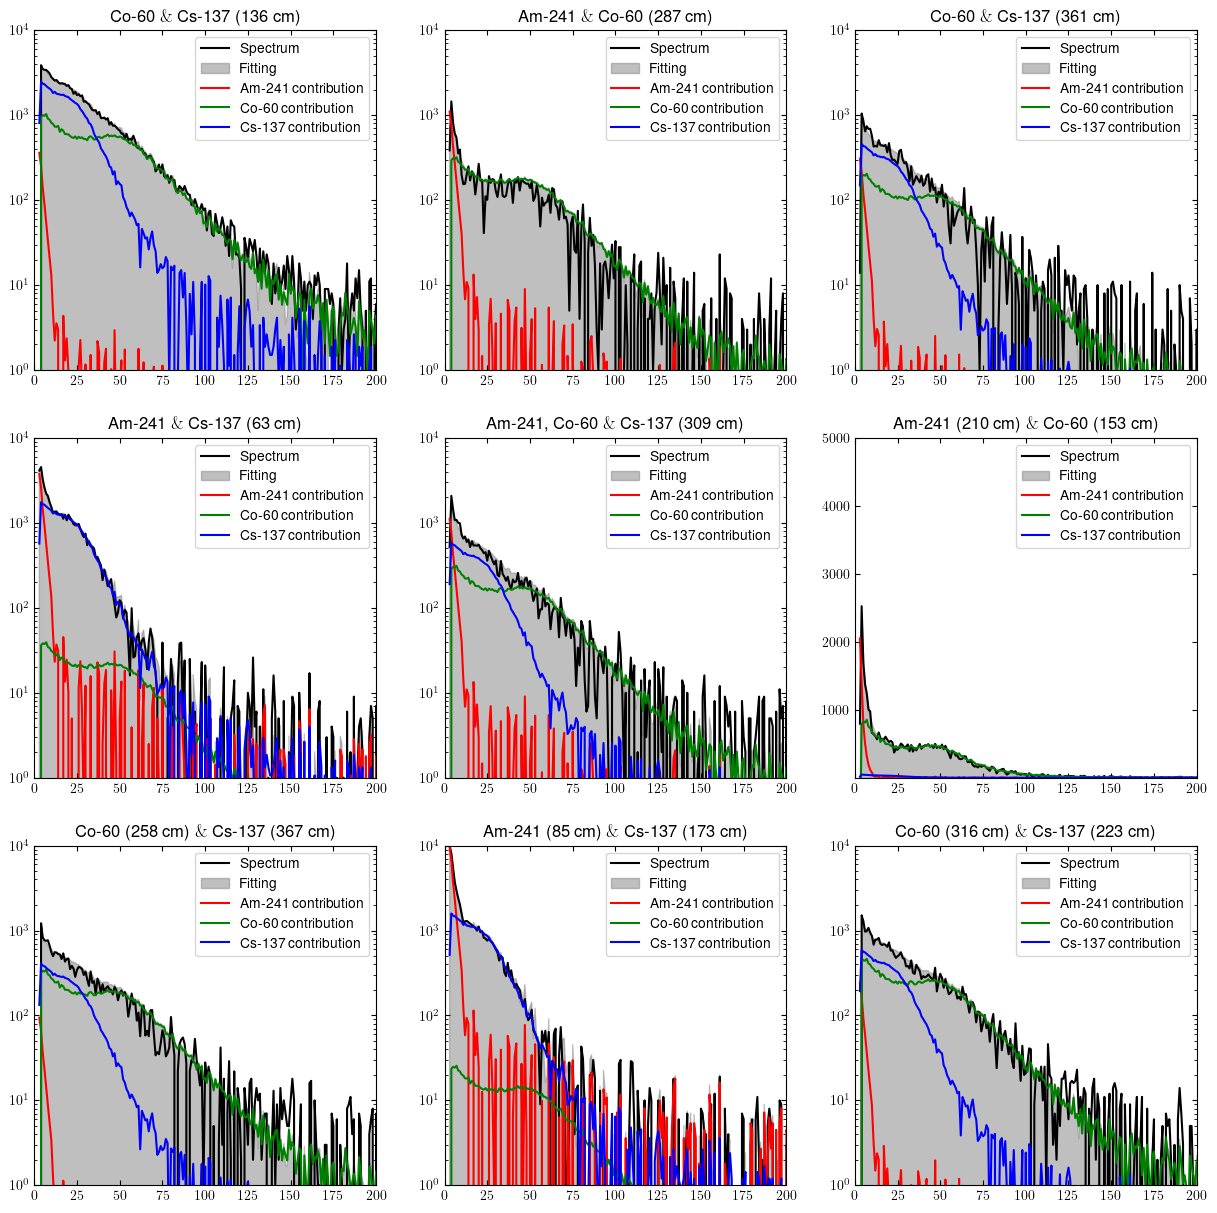

In [16]:
chan1, chan2 = 0, 200
y0, y1 = 1, 1e4
plt.figure(figsize=(15, 15))#, dpi=300)
plt.subplot(331)
kk = "co_cs_136"
plt.plot(channel, RAWSub1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"] + RawSubFitResult[kk]['co'][0] * _refspecSub["Co"] + RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, RawSubFitResult[kk]['co'][0] * _refspecSub["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Co-60 $\\&$ Cs-137 (136 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
plt.yscale("log", base=10)

plt.legend()

plt.subplot(332)
kk = "am_co_287"
plt.plot(channel, RAWSub1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"] + RawSubFitResult[kk]['co'][0] * _refspecSub["Co"] + RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, RawSubFitResult[kk]['co'][0] * _refspecSub["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Am-241 $\\&$ Co-60 (287 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(333)
kk = "co_cs_361"
plt.plot(channel, RAWSub1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"] + RawSubFitResult[kk]['co'][0] * _refspecSub["Co"] + RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, RawSubFitResult[kk]['co'][0] * _refspecSub["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Co-60 $\\&$ Cs-137 (361 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(334)
kk = 'am_cs_163'
plt.plot(channel, RAWSub1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"] + RawSubFitResult[kk]['co'][0] * _refspecSub["Co"] + RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, RawSubFitResult[kk]['co'][0] * _refspecSub["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title( "Am-241 $\\&$ Cs-137 (63 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(335)
kk = 'am_co_cs_309'
plt.plot(channel, RAWSub1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"] + RawSubFitResult[kk]['co'][0] * _refspecSub["Co"] + RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, RawSubFitResult[kk]['co'][0] * _refspecSub["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Am-241, Co-60 $\\&$ Cs-137 (309 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(336)
kk = 'am_210_co_153'
plt.plot(channel, RAWSub1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"] + RawSubFitResult[kk]['co'][0] * _refspecSub["Co"] + RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, RawSubFitResult[kk]['co'][0] * _refspecSub["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Am-241 (210 cm) $\\&$ Co-60 (153 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1/2)
plt.legend(loc=1)

plt.subplot(337)
kk = 'co_285_cs_367'
plt.plot(channel, RAWSub1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"] + RawSubFitResult[kk]['co'][0] * _refspecSub["Co"] + RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, RawSubFitResult[kk]['co'][0] * _refspecSub["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Co-60 (258 cm) $\\&$ Cs-137 (367 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(338)
kk = 'am_85_cs_173'
plt.plot(channel, RAWSub1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"] + RawSubFitResult[kk]['co'][0] * _refspecSub["Co"] + RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, RawSubFitResult[kk]['co'][0] * _refspecSub["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Am-241 (85 cm) $\\&$ Cs-137 (173 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
plt.yscale("log", base=10)
plt.legend()

plt.subplot(339)
kk = 'co_316_cs_223'
plt.plot(channel, RAWSub1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"] + RawSubFitResult[kk]['co'][0] * _refspecSub["Co"] + RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, RawSubFitResult[kk]['am'][0] * _refspecSub["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, RawSubFitResult[kk]['co'][0] * _refspecSub["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, RawSubFitResult[kk]['cs'][0] * _refspecSub["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Co-60 (316 cm) $\\&$ Cs-137 (223 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
plt.yscale("log", base=10)
plt.legend()

# plt.savefig("../../src/newfigures/fit_BGRto.pdf")
#plt.savefig("../../papers/ver260326Moon_revision01/newfigures/fit_BGRto.pdf")

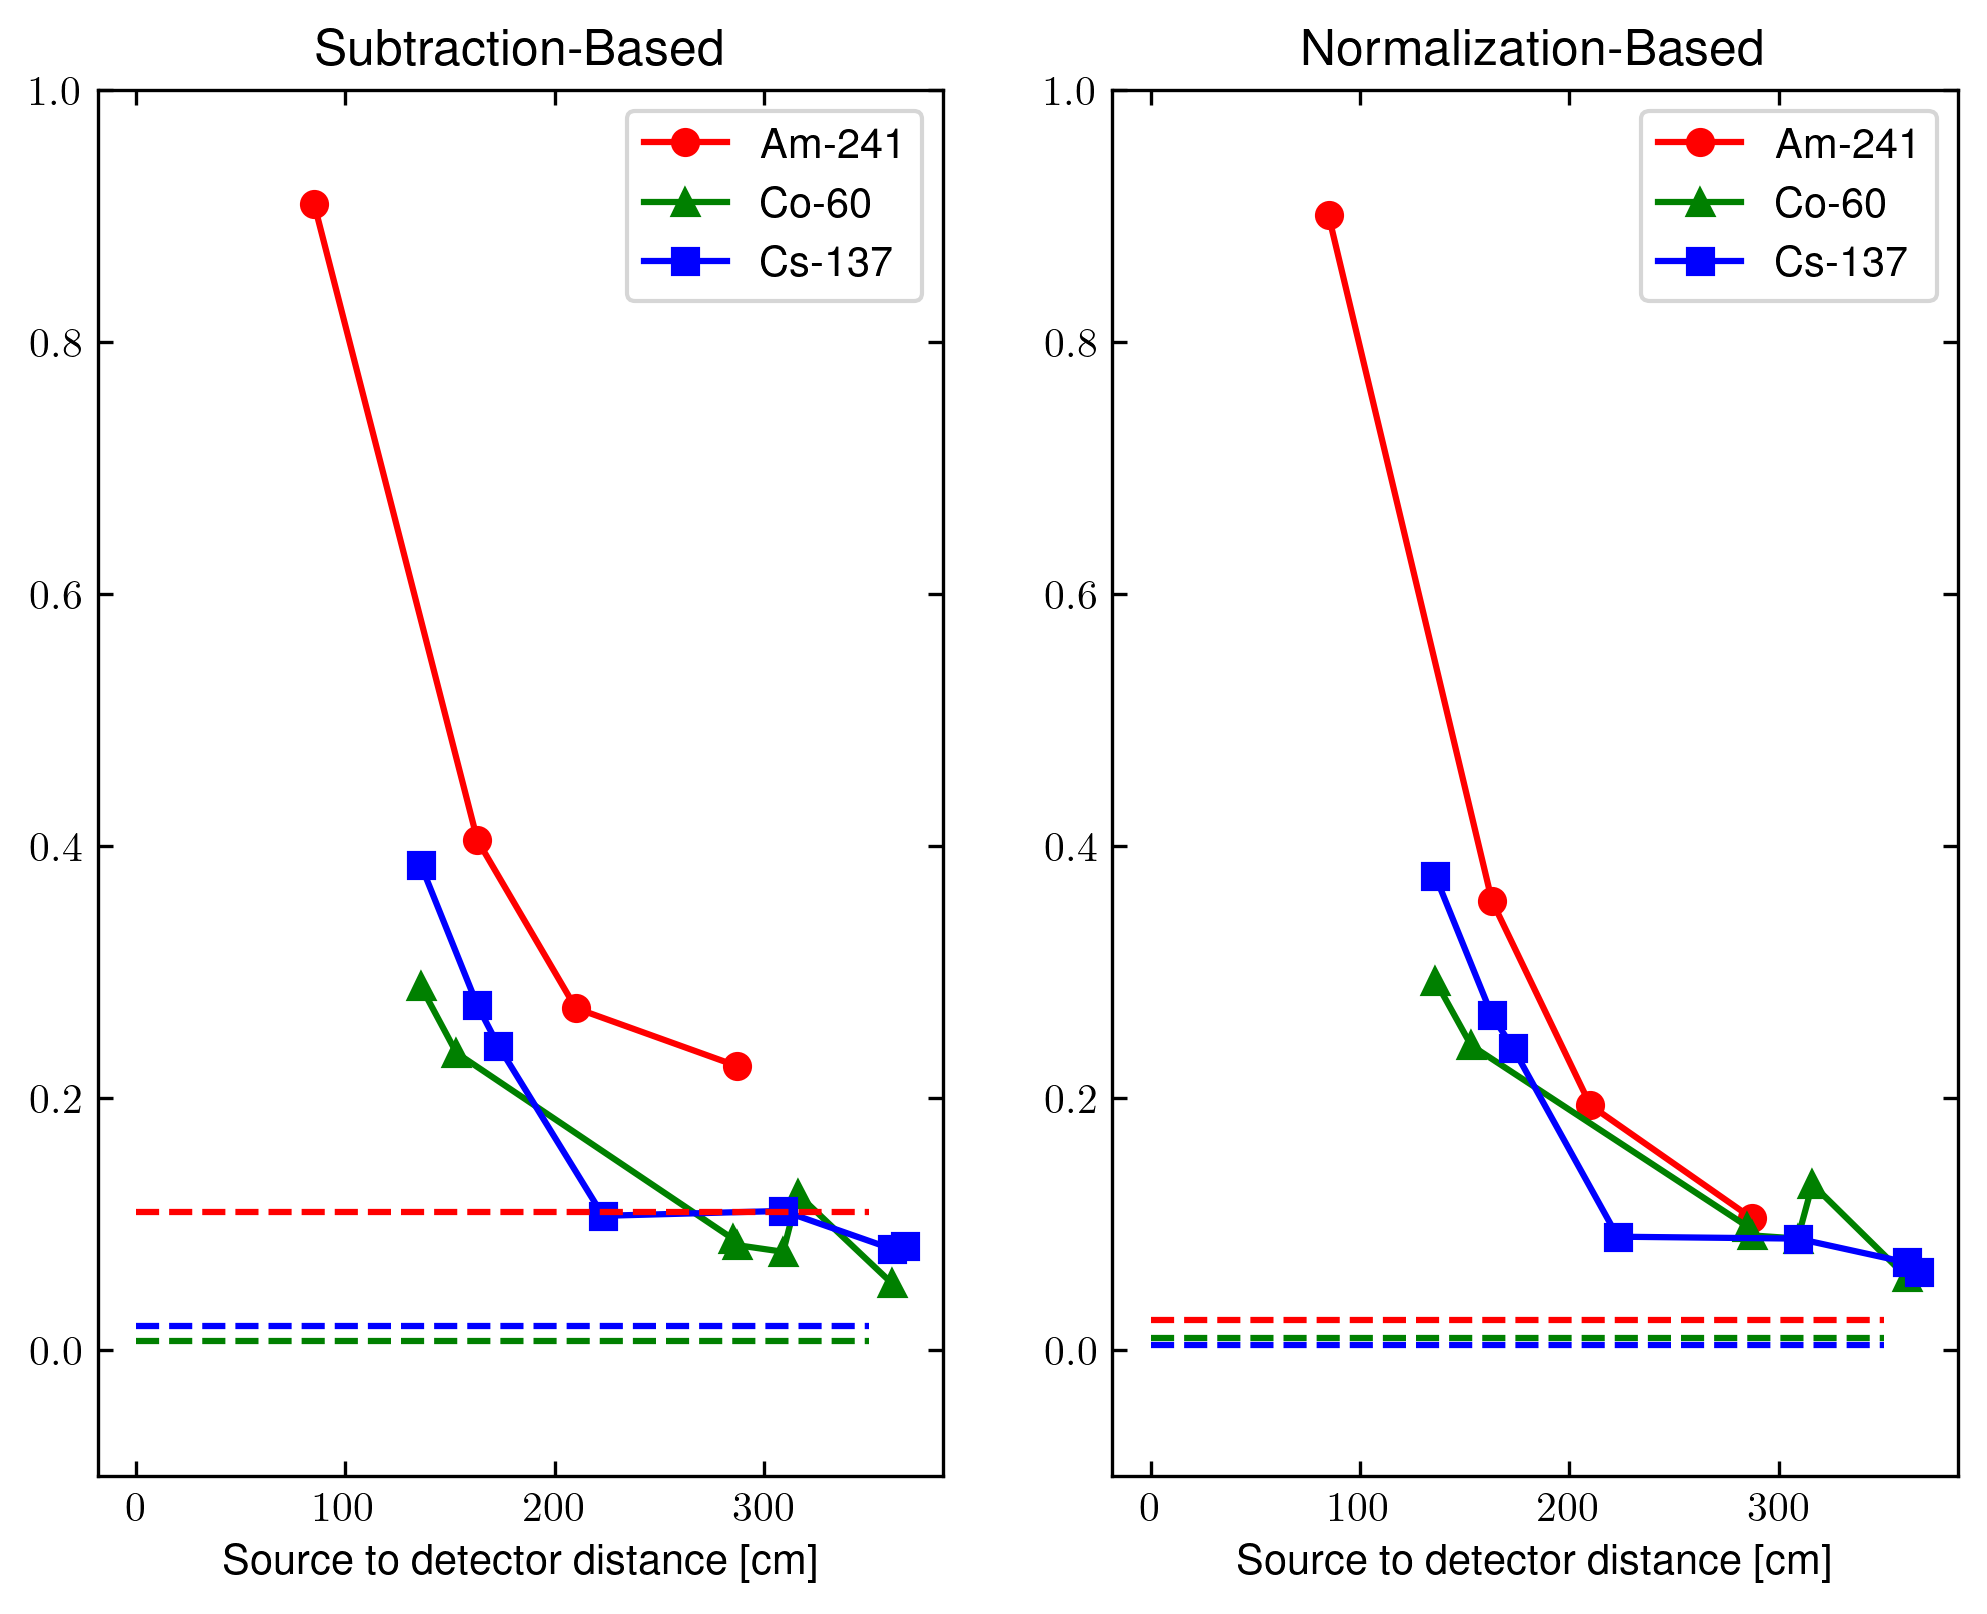

In [17]:
plt.figure(figsize=(8, 6), dpi=300)

plt.subplot(121)
amx = np.array([287, 163, 210, 85])
amy = np.array([RawFitResult["am_co_287"]["am"][0], RawFitResult["am_cs_163"]["am"][0], RawFitResult["am_210_co_153"]["am"][0], RawFitResult["am_85_cs_173"]["am"][0]])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")

cox = np.array([136, 287, 361, 309, 153, 285, 316])
coy = np.array([RawFitResult["co_cs_136"]["co"][0], RawFitResult["am_co_287"]["co"][0], RawFitResult["co_cs_361"]["co"][0], RawFitResult["am_co_cs_309"]["co"][0], RawFitResult["am_210_co_153"]["co"][0], RawFitResult["co_285_cs_367"]["co"][0], RawFitResult["co_316_cs_223"]["co"][0]])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 223])
csy = np.array([RawFitResult["co_cs_136"]["cs"][0], RawFitResult["co_cs_361"]["cs"][0], RawFitResult["am_cs_163"]["cs"][0], RawFitResult["am_co_cs_309"]["cs"][0], RawFitResult["co_285_cs_367"]["cs"][0], RawFitResult["am_85_cs_173"]["cs"][0], RawFitResult["co_316_cs_223"]["cs"][0]])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(-0.1, 1)
plt.xlabel("Source to detector distance [cm]")

amzero, cozero, cszero, qs= [] , [], [], []

for ks in mixed :
     if "am" not in ks :
          amzero.append(RawFitResult[ks]["am"][0])
          
     if "co" not in ks :
          cozero.append(RawFitResult[ks]["co"][0])
          
     if "cs" not in ks :
          cszero.append(RawFitResult[ks]["cs"][0])
          qs.append(ks)

plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )

plt.title("Subtraction-Based")
plt.legend()

plt.subplot(122)
amx = np.array([287, 163, 210, 85])
amy = np.array([RawSubFitResult["am_co_287"]["am"][0], RawSubFitResult["am_cs_163"]["am"][0], RawSubFitResult["am_210_co_153"]["am"][0], RawSubFitResult["am_85_cs_173"]["am"][0]])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")
plt.title("Background Subtracted Method")
plt.legend()

cox = np.array([136, 287, 361, 309, 153, 285, 316])
coy = np.array([RawSubFitResult["co_cs_136"]["co"][0], RawSubFitResult["am_co_287"]["co"][0], RawSubFitResult["co_cs_361"]["co"][0], RawSubFitResult["am_co_cs_309"]["co"][0], RawSubFitResult["am_210_co_153"]["co"][0], RawSubFitResult["co_285_cs_367"]["co"][0], RawSubFitResult["co_316_cs_223"]["co"][0]])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 223])
csy = np.array([RawSubFitResult["co_cs_136"]["cs"][0], RawSubFitResult["co_cs_361"]["cs"][0], RawSubFitResult["am_cs_163"]["cs"][0], RawSubFitResult["am_co_cs_309"]["cs"][0], RawSubFitResult["co_285_cs_367"]["cs"][0], RawSubFitResult["am_85_cs_173"]["cs"][0], RawSubFitResult["co_316_cs_223"]["cs"][0]])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(-0.1, 1)
plt.xlabel("Source to detector distance [cm]")

amzero, cozero, cszero, qs= [] , [], [], []

for ks in mixed :
     if "am" not in ks :
          amzero.append(RawSubFitResult[ks]["am"][0])
          
     if "co" not in ks :
          cozero.append(RawSubFitResult[ks]["co"][0])
          
     if "cs" not in ks :
          cszero.append(RawSubFitResult[ks]["cs"][0])
          qs.append(ks)

plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )

plt.title("Normalization-Based")
plt.legend()


#plt.savefig("../../papers/ver260326Moon_revision01/newfigures/fit_contributions.pdf")

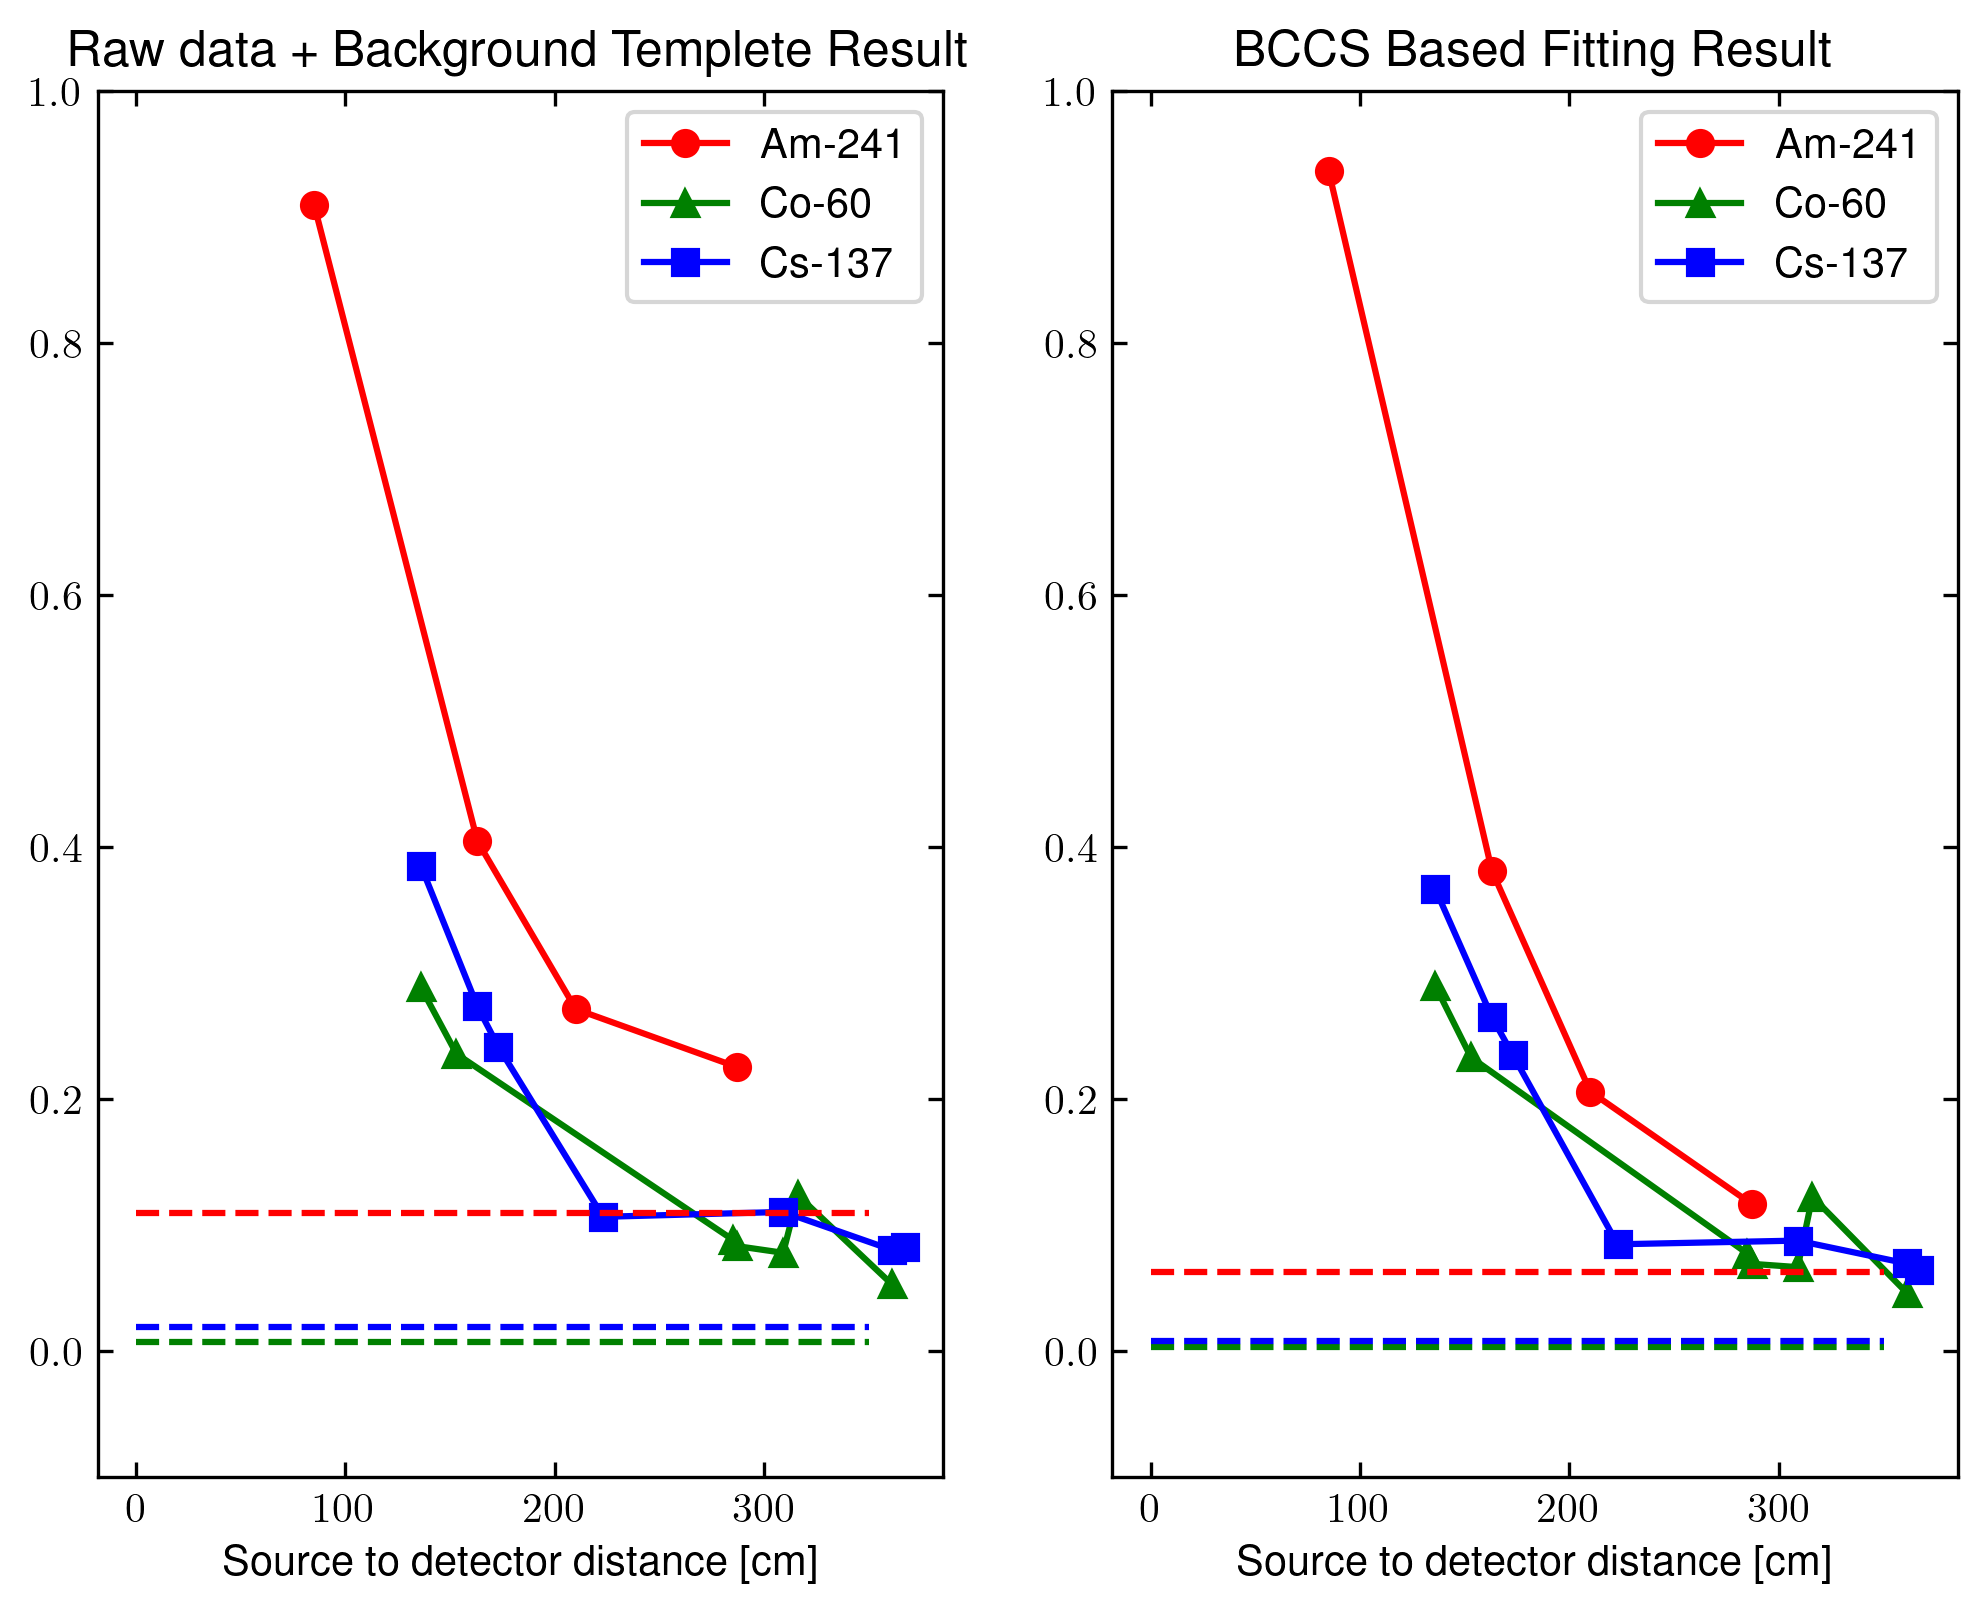

In [25]:
BCCSFitSubResult = {'co_cs_136': {'am': [0.08754377914572177, 0.00600549403638841],
  'co': [0.2895590714207633, 0.0018310993905879189],
  'cs': [0.36635517897043285, 0.0018310993905879189]},
 'am_co_287': {'am': [0.11664139866654827, 0.006005493699500455],
  'co': [0.06912329958256519, 0.001831099392697166],
  'cs': [0.0071543359310947685, 0.001831099392697166]},
 'co_cs_361': {'am': [0.05688760152642533, 0.006005493715295424],
  'co': [0.046252140862939245, 0.0018310993788839644],
  'cs': [0.0694057959693339, 0.0018310993788839644]},
 'am_cs_163': {'am': [0.3809662818098908, 0.0060054935992490885],
  'co': [0.0023954439773308245, 0.0018310995009680156],
  'cs': [0.26488068994689035, 0.0018310995009680156]},
 'am_co_cs_309': {'am': [0.15891337641329, 0.006005493795826648],
  'co': [0.0664894102688744, 0.0018310993717202437],
  'cs': [0.08755945271979387, 0.0018310993717202437]},
 'am_210_co_153': {'am': [0.20578585255190185, 0.006005493854497622],
  'co': [0.23298101368531904, 0.0018310993549437856],
  'cs': [0.008197661213510843, 0.0018310993549437856]},
 'co_285_cs_367': {'am': [0.04303515256699508, 0.00600549322607556],
  'co': [0.07723378136342902, 0.0018310993698161132],
  'cs': [0.06438390400893908, 0.0018310993698161132]},
 'am_85_cs_173': {'am': [0.9365830117006839, 0.006005493654198182],
  'co': [0.004284967539097129, 0.0018310993915484147],
  'cs': [0.2348020461877121, 0.0018310993915484147]},
 'co_316_cs_223': {'am': [0.06397235150935515, 0.006005493237489164],
  'co': [0.1223597711558006, 0.0018310993758794659],
  'cs': [0.0846179805440086, 0.0018310993758794659]}}

plt.figure(figsize=(8, 6), dpi=300)

plt.subplot(121)
amx = np.array([287, 163, 210, 85])
amy = np.array([RawFitResult["am_co_287"]["am"][0], RawFitResult["am_cs_163"]["am"][0], RawFitResult["am_210_co_153"]["am"][0], RawFitResult["am_85_cs_173"]["am"][0]])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")

cox = np.array([136, 287, 361, 309, 153, 285, 316])
coy = np.array([RawFitResult["co_cs_136"]["co"][0], RawFitResult["am_co_287"]["co"][0], RawFitResult["co_cs_361"]["co"][0], RawFitResult["am_co_cs_309"]["co"][0], RawFitResult["am_210_co_153"]["co"][0], RawFitResult["co_285_cs_367"]["co"][0], RawFitResult["co_316_cs_223"]["co"][0]])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 223])
csy = np.array([RawFitResult["co_cs_136"]["cs"][0], RawFitResult["co_cs_361"]["cs"][0], RawFitResult["am_cs_163"]["cs"][0], RawFitResult["am_co_cs_309"]["cs"][0], RawFitResult["co_285_cs_367"]["cs"][0], RawFitResult["am_85_cs_173"]["cs"][0], RawFitResult["co_316_cs_223"]["cs"][0]])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(-0.1, 1)
plt.xlabel("Source to detector distance [cm]")

amzero, cozero, cszero, qs= [] , [], [], []

for ks in mixed :
     if "am" not in ks :
          amzero.append(RawFitResult[ks]["am"][0])
          
     if "co" not in ks :
          cozero.append(RawFitResult[ks]["co"][0])
          
     if "cs" not in ks :
          cszero.append(RawFitResult[ks]["cs"][0])
          qs.append(ks)

plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )
plt.title("Raw data + Background Templete Result")

plt.legend()

plt.subplot(122)
amx = np.array([287, 163, 210, 85])
amy = np.array([BCCSFitSubResult["am_co_287"]["am"][0], BCCSFitSubResult["am_cs_163"]["am"][0], BCCSFitSubResult["am_210_co_153"]["am"][0], BCCSFitSubResult["am_85_cs_173"]["am"][0]])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")
plt.title("Background Subtracted Method")
plt.legend()

cox = np.array([136, 287, 361, 309, 153, 285, 316])
coy = np.array([BCCSFitSubResult["co_cs_136"]["co"][0], BCCSFitSubResult["am_co_287"]["co"][0], BCCSFitSubResult["co_cs_361"]["co"][0], BCCSFitSubResult["am_co_cs_309"]["co"][0], BCCSFitSubResult["am_210_co_153"]["co"][0], BCCSFitSubResult["co_285_cs_367"]["co"][0], BCCSFitSubResult["co_316_cs_223"]["co"][0]])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 223])
csy = np.array([BCCSFitSubResult["co_cs_136"]["cs"][0], BCCSFitSubResult["co_cs_361"]["cs"][0], BCCSFitSubResult["am_cs_163"]["cs"][0], BCCSFitSubResult["am_co_cs_309"]["cs"][0], BCCSFitSubResult["co_285_cs_367"]["cs"][0], BCCSFitSubResult["am_85_cs_173"]["cs"][0], BCCSFitSubResult["co_316_cs_223"]["cs"][0]])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(-0.1, 1)
plt.xlabel("Source to detector distance [cm]")

amzero, cozero, cszero, qs= [] , [], [], []

for ks in mixed :
     if "am" not in ks :
          amzero.append(BCCSFitSubResult[ks]["am"][0])
          
     if "co" not in ks :
          cozero.append(BCCSFitSubResult[ks]["co"][0])
          
     if "cs" not in ks :
          cszero.append(BCCSFitSubResult[ks]["cs"][0])
          qs.append(ks)

plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )

plt.title("BCCS Based Fitting Result")
plt.legend()


plt.savefig("bccs_raw_comparison.pdf")

In [21]:
BCCSFitSubResult = {'co_cs_136': {'am': [0.08754377914572177, 0.00600549403638841],
  'co': [0.2895590714207633, 0.0018310993905879189],
  'cs': [0.36635517897043285, 0.0018310993905879189]},
 'am_co_287': {'am': [0.11664139866654827, 0.006005493699500455],
  'co': [0.06912329958256519, 0.001831099392697166],
  'cs': [0.0071543359310947685, 0.001831099392697166]},
 'co_cs_361': {'am': [0.05688760152642533, 0.006005493715295424],
  'co': [0.046252140862939245, 0.0018310993788839644],
  'cs': [0.0694057959693339, 0.0018310993788839644]},
 'am_cs_163': {'am': [0.3809662818098908, 0.0060054935992490885],
  'co': [0.0023954439773308245, 0.0018310995009680156],
  'cs': [0.26488068994689035, 0.0018310995009680156]},
 'am_co_cs_309': {'am': [0.15891337641329, 0.006005493795826648],
  'co': [0.0664894102688744, 0.0018310993717202437],
  'cs': [0.08755945271979387, 0.0018310993717202437]},
 'am_210_co_153': {'am': [0.20578585255190185, 0.006005493854497622],
  'co': [0.23298101368531904, 0.0018310993549437856],
  'cs': [0.008197661213510843, 0.0018310993549437856]},
 'co_285_cs_367': {'am': [0.04303515256699508, 0.00600549322607556],
  'co': [0.07723378136342902, 0.0018310993698161132],
  'cs': [0.06438390400893908, 0.0018310993698161132]},
 'am_85_cs_173': {'am': [0.9365830117006839, 0.006005493654198182],
  'co': [0.004284967539097129, 0.0018310993915484147],
  'cs': [0.2348020461877121, 0.0018310993915484147]},
 'co_316_cs_223': {'am': [0.06397235150935515, 0.006005493237489164],
  'co': [0.1223597711558006, 0.0018310993758794659],
  'cs': [0.0846179805440086, 0.0018310993758794659]}}

In [26]:
RawFitResult

{'co_cs_136': {'am': [0.0885061105455027, 0.015190158592054113],
  'co': [0.2885794855514817, 0.01036519245707222],
  'cs': [0.3849542531402762, 0.009371307905079174],
  'bkg': [0.9739774751642092, 0.010110775426893693]},
 'am_co_287': {'am': [0.2252863565893504, 0.015190156593898385],
  'co': [0.08315417313085502, 0.010365192737271657],
  'cs': [0.018036956940019524, 0.009371307490581548],
  'bkg': [0.9426689300624985, 0.010110773688360818]},
 'co_cs_361': {'am': [0.09398998034611623, 0.01519015779219606],
  'co': [0.0527474024503203, 0.010365192608362798],
  'cs': [0.08013495656751862, 0.00937130763377108],
  'bkg': [0.968986569380839, 0.010110774747205014]},
 'am_cs_163': {'am': [0.40453605477437177, 0.015190155850170263],
  'co': [0.007347710945954822, 0.010365188483938767],
  'cs': [0.27343672766210037, 0.009371313385242707],
  'bkg': [0.9769219033516059, 0.010110777358348364]},
 'am_co_cs_309': {'am': [0.23839787142921146, 0.01519015715770738],
  'co': [0.07787843987146514, 0.010

In [ ]:
CCC = {}
for kk in RawFitResult.keys():
    CCC[kk] = {"Raw" }

co_cs_136
am_co_287
co_cs_361
am_cs_163
am_co_cs_309
am_210_co_153
co_285_cs_367
am_85_cs_173
co_316_cs_223
